![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 4. Process Design Kit (PDK) and Layout

## 1. Technology

We will work with the **demo UPVfab PDK**. (There are some other open-source PDKs, in other technologies, feel free to search if interested)

Let's view the layer distribution of this PDK. In our case, for the passive devices we will only use the **Layer 1**. 

2026-06-12 14:48:42.433 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


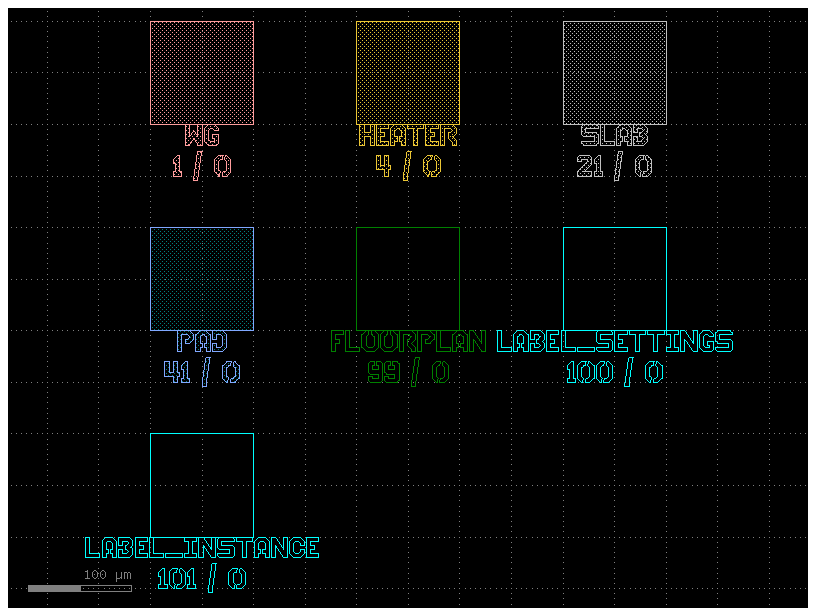

In [1]:
import gdsfactory as gf
from upvfab.sin300.cband import PDK, cells
LAYER_VIEWS = PDK.layer_views
c = LAYER_VIEWS.preview_layerset()
c.show()
c.plot()


The new versions of GDS Factory allow to view the Layer Stack also (3D view of the fabrication flow). The following code allows to generate and view the Layer Stack of the generic PDK. Reference: https://www.degruyter.com/document/doi/10.1515/nanoph-2013-0034/html

The layers and the thicknesses have been defined previously on the PDK, so it is possible to view in 3D some of the components in the PDK. 

See the [Reference Manual](https://gdsfactory.github.io/gdsfactory/components.html) and read the list of the available components.

Here are some examples of the 3D views of this photonic components

In [2]:
# xs = gf.cross_section.strip(width=0.5, layer = 'WG')

# c = gf.components.straight(length=10, cross_section=xs)  #Deep 
# c.plot() # To view the component on Notebook
# c.show() # To view on KLayout
# scene = c.to_3d()
# scene.show()


In [3]:
# c = gf.components.straight(length=5, cross_section='rib') #Shallow
# c.plot()
# c.show()

# scene = c.to_3d()
# c.show()
# scene.show()

In [4]:
# c = cells.taper_strip_to_ridge(length=10) #Taper
# c.show()

# scene = c.to_3d()
# scene.show()

In [5]:
# c = cells.straight_heater_metal()

# #c.pprint_ports()

# c.plot()
# c.show()
# #c.draw_ports()

# scene = c.to_3d()
# scene.show()

- Use your design results from Lab2 and Lab3 to create **layout** instances of your designed components: DCs, MMIs, MZIs & Ring Resonators. 

### Directional  Coupler (DC)

┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center         ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ in1  │ 5.0   │ 180.0       │ WG (1/0) │ (-40.0, -10.0) │ optical   │
│ in0  │ 5.0   │ 180.0       │ WG (1/0) │ (-40.0, 20.0)  │ optical   │
│ out1 │ 5.0   │ 0.0         │ WG (1/0) │ (80.0, -10.0)  │ optical   │
│ out0 │ 5.0   │ 0.0         │ WG (1/0) │ (80.0, 20.0)   │ optical   │
└──────┴───────┴─────────────┴──────────┴────────────────┴───────────┘

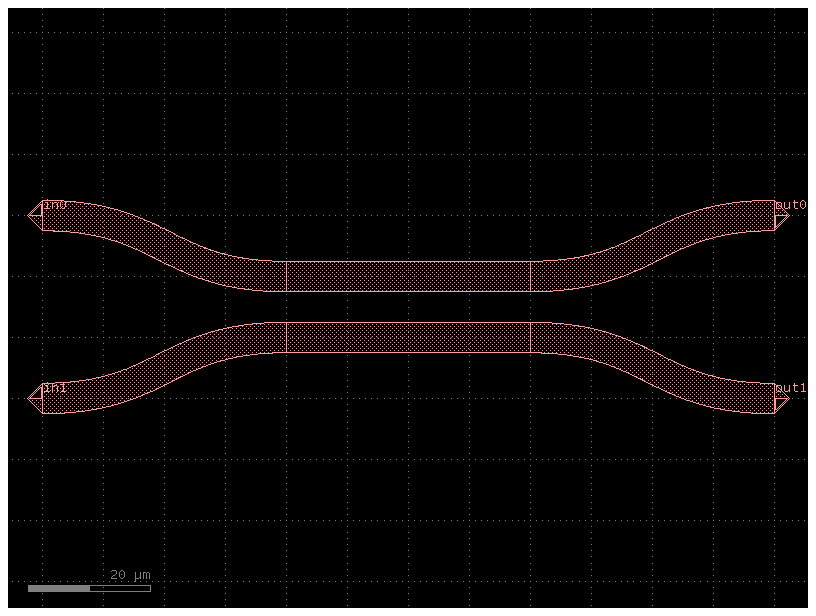

In [6]:
gf.clear_cache()

# Parámetros usados en el DC 2x2 K = 0.5 en lab2
# wg_gap = 1.2
# wg_width = 1.2
# Lpi = 580
# length = Lpi / 2 # K = 0.5

# Se ha redimensionado para una mejor visualización
wg_gap = 5          # Separación entre las dos guías del acoplador
wg_width = 5        # Anchura de las guías
Lpi = 80            # Longitud Lpi del acoplador direccional
length = Lpi / 2    # Longitud para K = 0.5

acoplador = gf.Component()

# Cross-section
xs = gf.cross_section.strip(width=wg_width, layer="WG")

# Creamos los componentes
recta = gf.components.straight(length=length, cross_section=xs)
codo_arriba = gf.components.bend_s(size=(length, (wg_gap + wg_width)), cross_section=xs)
codo_abajo = gf.components.bend_s(size=(length, -(wg_gap + wg_width)), cross_section=xs)

# Añadimos los cuatros codos
codoSW = acoplador.add_ref(codo_arriba)
codoNW = acoplador.add_ref(codo_abajo)
codoSE = acoplador.add_ref(codo_abajo)
codoNE = acoplador.add_ref(codo_arriba)

# Añadimos las dos rectas
rectaN = acoplador.add_ref(recta)
rectaS = acoplador.add_ref(recta)

# Movemos y conectamos
rectaN.movey(wg_gap + wg_width)
codoSW.connect("o2", rectaS.ports["o1"])
codoNW.connect("o2", rectaN.ports["o1"])
codoSE.connect("o1", rectaS.ports["o2"])
codoNE.connect("o1", rectaN.ports["o2"])

# Puertos exteriores:
acoplador.add_port("in1", port=codoSW.ports["o1"])
acoplador.add_port("in0", port=codoNW.ports["o1"])
acoplador.add_port("out1", port=codoSE.ports["o2"])
acoplador.add_port("out0", port=codoNE.ports["o2"])

# Visualización
acoplador.pprint_ports()
acoplador.draw_ports()
acoplador.plot()


In [7]:
@gf.cell
def acoplador2x2(wg_gap, wg_width, Lpi, xs): 
    length = Lpi / 2
    
    acoplador = gf.Component()

    # Creamos los componentes
    recta = gf.components.straight(length=length, cross_section=xs)
    codo_arriba = gf.components.bend_s(size=(length, (wg_gap + wg_width)), cross_section=xs)
    codo_abajo = gf.components.bend_s(size=(length, -(wg_gap + wg_width)), cross_section=xs)

    # Añadimos los cuatros codos
    codoSW = acoplador.add_ref(codo_arriba)
    codoNW = acoplador.add_ref(codo_abajo)
    codoSE = acoplador.add_ref(codo_abajo)
    codoNE = acoplador.add_ref(codo_arriba)

    # Añadimos las dos rectas
    rectaN = acoplador.add_ref(recta)
    rectaS = acoplador.add_ref(recta)

    # Movemos y conectamos
    rectaN.movey(wg_gap + wg_width)
    codoSW.connect("o2", rectaS.ports["o1"])
    codoNW.connect("o2", rectaN.ports["o1"])
    codoSE.connect("o1", rectaS.ports["o2"])
    codoNE.connect("o1", rectaN.ports["o2"])

    # Puertos exteriores:
    acoplador.add_port("in1", port=codoSW.ports["o1"])
    acoplador.add_port("in0", port=codoNW.ports["o1"])
    acoplador.add_port("out1", port=codoSE.ports["o2"])
    acoplador.add_port("out0", port=codoNE.ports["o2"])
    return acoplador


### MMIs

┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center                                    ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ in0  │ 1.0   │ 180.0       │ WG (1/0) │ (-8.0, 1.1500000000000001)                │ optical   │
│ in1  │ 1.0   │ 180.0       │ WG (1/0) │ (-8.0, -1.1500000000000001)               │ optical   │
│ out0 │ 1.0   │ 0.0         │ WG (1/0) │ (42.800000000000004, 1.1500000000000001)  │ optical   │
│ out1 │ 1.0   │ 0.0         │ WG (1/0) │ (42.800000000000004, -1.1500000000000001) │ optical   │
└──────┴───────┴─────────────┴──────────┴───────────────────────────────────────────┴───────────┘

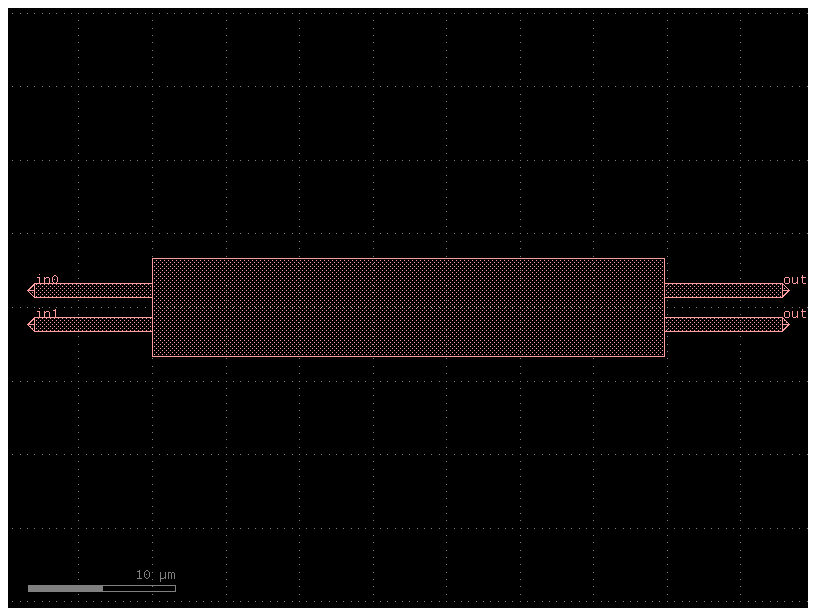

In [8]:
import numpy as np

gf.clear_cache()

# Parámetros usados en el MMI 2x2 K = 0.5 en lab2
mmi_Width = 6.6      # Anchura del rectángulo central del MMI
wg_width_dw = 1      # Anchura de las guías de entrada y salida
length = 8           # Longitud de las guías rectas de entrada y salida
Lpi = 69             # Longitud Lpi del MMI
dy = 0.05            # Desplazamiento vertical adicional de las guías
dL_MMI = -0.3        # Corrección de longitud aplicada al MMI

L_MMI = (1/2)*Lpi - dL_MMI
IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])
OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])

mmi = gf.Component()

# Cross-section
xs = gf.cross_section.strip(width=wg_width_dw, layer="WG")

# Creamos los componentes
rectangulo = gf.components.rectangle(size=(L_MMI, mmi_Width), layer="WG")
recta = gf.components.straight(length=length, cross_section=xs)

# Añadimos rectangulo central
rectanguloCentral = mmi.add_ref(rectangulo)

# Añadimos las cuatro rectas entrada y salida
recta1 = mmi.add_ref(recta)
recta2 = mmi.add_ref(recta)
recta3 = mmi.add_ref(recta)
recta4 = mmi.add_ref(recta)

# Movemos rectas in
recta1.movex(-length)
recta2.movex(-length)
recta1.movey(IN_WVG_positions[1])
recta2.movey(IN_WVG_positions[0])

# Movemos rectangulo
rectanguloCentral.movey(-mmi_Width / 2)

# Movemos rectas out
recta3.movex(L_MMI)
recta4.movex(L_MMI)
recta3.movey(OUT_WVG_positions[1])
recta4.movey(OUT_WVG_positions[0])

# Puertos exteriores:
mmi.add_port("in0", port=recta1.ports["o1"])
mmi.add_port("in1", port=recta2.ports["o1"])
mmi.add_port("out0", port=recta3.ports["o2"])
mmi.add_port("out1", port=recta4.ports["o2"])

# Visualización
mmi.pprint_ports()
mmi.draw_ports()
mmi.plot()


In [9]:
# @gf.cell
# def mmi(mmi_Width, wg_width_dw, length, Lpi, dy, dL_MMI, xs):
#     L_MMI = (1/2)*Lpi - dL_MMI
#     IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])
#     OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])

#     mmi = gf.Component()

#     # Creamos los componentes
#     rectangulo = gf.components.rectangle(size=(L_MMI, mmi_Width), layer="WG")
#     recta = gf.components.straight(length=length, cross_section=xs)

#     # Añadimos rectangulo central
#     rectanguloCentral = mmi.add_ref(rectangulo)

#     # Añadimos las cuatro rectas entrada y salida
#     recta1 = mmi.add_ref(recta)
#     recta2 = mmi.add_ref(recta)
#     recta3 = mmi.add_ref(recta)
#     recta4 = mmi.add_ref(recta)

#     # Movemos rectas in
#     recta1.movex(-length)
#     recta2.movex(-length)
#     recta1.movey(IN_WVG_positions[1])
#     recta2.movey(IN_WVG_positions[0])

#     # Movemos rectangulo
#     rectanguloCentral.movey(-mmi_Width / 2)

#     # Movemos rectas out
#     recta3.movex(L_MMI)
#     recta4.movex(L_MMI)
#     recta3.movey(OUT_WVG_positions[1])
#     recta4.movey(OUT_WVG_positions[0])

#     # Puertos exteriores:
#     mmi.add_port("in0", port=recta1.ports["o1"])
#     mmi.add_port("in1", port=recta2.ports["o1"])
#     mmi.add_port("out0", port=recta3.ports["o2"])
#     mmi.add_port("out1", port=recta4.ports["o2"])
    
#     return mmi

# # Parámetros usados en el MMI 2x2 K = 0.5 en lab2
# mmi_Width = 6.6      # Anchura del rectángulo central del MMI
# wg_width_dw = 1      # Anchura de las guías de entrada y salida
# length = 8           # Longitud de las guías rectas de entrada y salida
# Lpi = 69             # Longitud Lpi del MMI
# dy = 0.05            # Desplazamiento vertical adicional de las guías
# dL_MMI = -0.3        # Corrección de longitud aplicada al MMI

# # Cross-section
# xs = gf.cross_section.strip(width=wg_width_dw, layer="WG")

# mmi = mmi(mmi_Width, wg_width_dw, length, Lpi, dy, dL_MMI, xs)

# # Visualización
# mmi.pprint_ports()
# mmi.draw_ports()
# mmi.plot()

### MZIs

┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center          ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ in0  │ 5.0   │ 180.0       │ WG (1/0) │ (-120.0, 0.0)   │ optical   │
│ in1  │ 5.0   │ 180.0       │ WG (1/0) │ (-120.0, -30.0) │ optical   │
│ out0 │ 5.0   │ 0.0         │ WG (1/0) │ (240.0, 0.0)    │ optical   │
│ out1 │ 5.0   │ 0.0         │ WG (1/0) │ (240.0, -30.0)  │ optical   │
└──────┴───────┴─────────────┴──────────┴─────────────────┴───────────┘

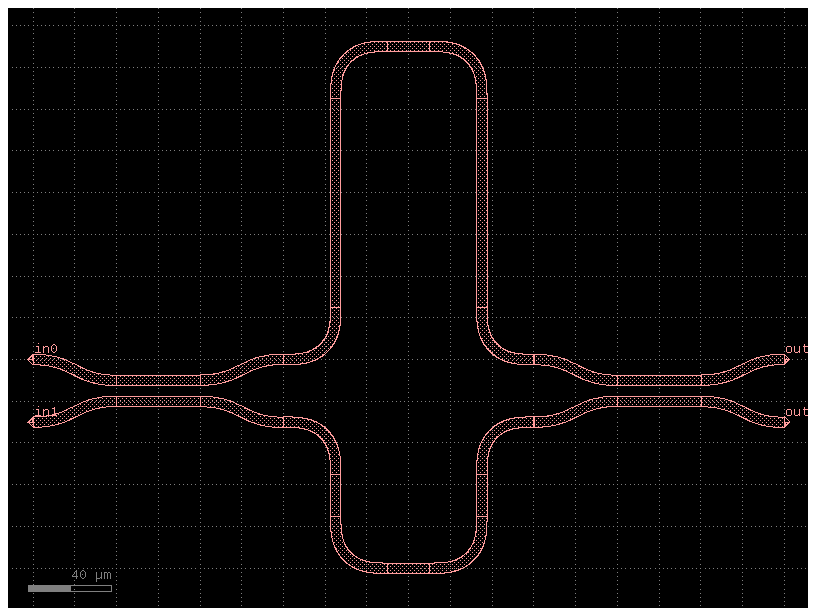

In [10]:
gf.clear_cache()
mzi = gf.Component()

wg_width = 5                    # Anchura de las guías de onda
acoplador_Lpi = 80              # Longitud Lpi del acoplador direccional 2x2
acoplador_wg_gap = 5            # Separación entre las dos guías del acoplador
recta_length_verticalN = 100    # Longitud de las rectas verticales del brazo superior
recta_length_verticalS = 20     # Longitud de las rectas verticales del brazo inferior
recta_length_horizontal = 20    # Longitud de las rectas horizontales centrales de cada brazo
codos90_radius = 25             # Radio de los codos Euler de 90 grados

# Cross-section
xs = gf.cross_section.strip(width=wg_width, layer="WG")

# Creamos los componentes 
acoplador = acoplador2x2(wg_gap=wg_width, wg_width=wg_width, Lpi=acoplador_Lpi, xs=xs)
recta_verticalN = gf.components.straight(length=recta_length_verticalN, cross_section=xs)
recta_verticalS = gf.components.straight(length=recta_length_verticalS, cross_section=xs)
recta_horizontal = gf.components.straight(length=recta_length_horizontal, cross_section=xs)
codo90_subida = gf.components.bend_euler(radius=codos90_radius, angle=90, cross_section=xs)
codo90_bajada = gf.components.bend_euler(radius=codos90_radius, angle=-90, cross_section=xs)

# Añadimos los componentes
acopladorW = mzi.add_ref(acoplador)
codo90_1 = mzi.add_ref(codo90_subida)
recta_vertical1 = mzi.add_ref(recta_verticalN)
codo90_2 = mzi.add_ref(codo90_bajada)
recta_horizontalN = mzi.add_ref(recta_horizontal)
codo90_3 = mzi.add_ref(codo90_bajada)
recta_vertical2 = mzi.add_ref(recta_verticalN)
codo90_4 = mzi.add_ref(codo90_subida)

acopladorE = mzi.add_ref(acoplador)
codo90_5 = mzi.add_ref(codo90_subida)
recta_vertical3 = mzi.add_ref(recta_verticalS)
codo90_6 = mzi.add_ref(codo90_bajada)
recta_horizontalS = mzi.add_ref(recta_horizontal)
codo90_7 = mzi.add_ref(codo90_bajada)
recta_vertical4 = mzi.add_ref(recta_verticalS)
codo90_8 = mzi.add_ref(codo90_subida)

# Realizamos las conexiones
acopladorW.connect("out0", codo90_1.ports["o1"])
recta_vertical1.connect("o1", codo90_1.ports["o2"])
codo90_2.connect("o1", recta_vertical1.ports["o2"])
recta_horizontalN.connect("o1", codo90_2.ports["o2"])
codo90_3.connect("o1", recta_horizontalN.ports["o2"])
recta_vertical2.connect("o1", codo90_3.ports["o2"])
codo90_4.connect("o1", recta_vertical2.ports["o2"])

acopladorE.connect("in0", codo90_4.ports["o2"])
codo90_5.connect("o1", acopladorE.ports["in1"])
recta_vertical3.connect("o1", codo90_5.ports["o2"])
codo90_6.connect("o1", recta_vertical3.ports["o2"])
recta_horizontalS.connect("o1", codo90_6.ports["o2"])
codo90_7.connect("o1", recta_horizontalS.ports["o2"])
recta_vertical4.connect("o1", codo90_7.ports["o2"])
codo90_8.connect("o1", recta_vertical4.ports["o2"])

# Puertos exteriores
mzi.add_port("in0", port=acopladorW.ports["in0"])
mzi.add_port("in1", port=acopladorW.ports["in1"])
mzi.add_port("out0", port=acopladorE.ports["out0"])
mzi.add_port("out1", port=acopladorE.ports["out1"])

# Visualización
mzi.pprint_ports()
mzi.draw_ports()
mzi.plot()

In [11]:
# @gf.cell
# def mzi(wg_width, acoplador_Lpi, acoplador_wg_gap, recta_length_verticalN, recta_length_verticalS, recta_length_horizontal, xs, codos90_radius): 
#     mzi = gf.Component()

#     # Creamos los componentes 
#     acoplador = acoplador2x2(acoplador_wg_gap, wg_width=wg_width, Lpi=acoplador_Lpi, xs=xs)
#     recta_verticalN = gf.components.straight(length=recta_length_verticalN, cross_section=xs)
#     recta_verticalS = gf.components.straight(length=recta_length_verticalS, cross_section=xs)
#     recta_horizontal = gf.components.straight(length=recta_length_horizontal, cross_section=xs)
#     codo90_subida = gf.components.bend_euler(radius=codos90_radius, angle=90, cross_section=xs)
#     codo90_bajada = gf.components.bend_euler(radius=codos90_radius, angle=-90, cross_section=xs)

#     # Añadimos los componentes
#     acopladorW = mzi.add_ref(acoplador)
#     codo90_1 = mzi.add_ref(codo90_subida)
#     recta_vertical1 = mzi.add_ref(recta_verticalN)
#     codo90_2 = mzi.add_ref(codo90_bajada)
#     recta_horizontalN = mzi.add_ref(recta_horizontal)
#     codo90_3 = mzi.add_ref(codo90_bajada)
#     recta_vertical2 = mzi.add_ref(recta_verticalN)
#     codo90_4 = mzi.add_ref(codo90_subida)

#     acopladorE = mzi.add_ref(acoplador)
#     codo90_5 = mzi.add_ref(codo90_subida)
#     recta_vertical3 = mzi.add_ref(recta_verticalS)
#     codo90_6 = mzi.add_ref(codo90_bajada)
#     recta_horizontalS = mzi.add_ref(recta_horizontal)
#     codo90_7 = mzi.add_ref(codo90_bajada)
#     recta_vertical4 = mzi.add_ref(recta_verticalS)
#     codo90_8 = mzi.add_ref(codo90_subida)


#     # Realizamos las conexiones
#     acopladorW.connect("out0", codo90_1.ports["o1"])
#     recta_vertical1.connect("o1", codo90_1.ports["o2"])
#     codo90_2.connect("o1", recta_vertical1.ports["o2"])
#     recta_horizontalN.connect("o1", codo90_2.ports["o2"])
#     codo90_3.connect("o1", recta_horizontalN.ports["o2"])
#     recta_vertical2.connect("o1", codo90_3.ports["o2"])
#     codo90_4.connect("o1", recta_vertical2.ports["o2"])

#     acopladorE.connect("in0", codo90_4.ports["o2"])
#     codo90_5.connect("o1", acopladorE.ports["in1"])
#     recta_vertical3.connect("o1", codo90_5.ports["o2"])
#     codo90_6.connect("o1", recta_vertical3.ports["o2"])
#     recta_horizontalS.connect("o1", codo90_6.ports["o2"])
#     codo90_7.connect("o1", recta_horizontalS.ports["o2"])
#     recta_vertical4.connect("o1", codo90_7.ports["o2"])
#     codo90_8.connect("o1", recta_vertical4.ports["o2"])


#     # Puertos exteriores
#     mzi.add_port("in0", port=acopladorW.ports["in0"])
#     mzi.add_port("in1", port=acopladorW.ports["in1"])
#     mzi.add_port("out0", port=acopladorE.ports["out0"])
#     mzi.add_port("out1", port=acopladorE.ports["out1"])
#     return mzi


# wg_width = 5                    # Anchura de las guías de onda
# acoplador_Lpi = 80              # Longitud Lpi del acoplador direccional 2x2
# acoplador_wg_gap = 5            # Separación entre las dos guías del acoplador
# recta_length_verticalN = 100    # Longitud de las rectas verticales del brazo superior
# recta_length_verticalS = 20     # Longitud de las rectas verticales del brazo inferior
# recta_length_horizontal = 20    # Longitud de las rectas horizontales centrales de cada brazo
# codos90_radius = 25             # Radio de los codos Euler de 90 grados

# # Cross-section
# xs = gf.cross_section.strip(width=wg_width, layer="WG")

# mzi = mzi(wg_width, acoplador_Lpi, acoplador_wg_gap, recta_length_verticalN, recta_length_verticalS, recta_length_horizontal, xs, codos90_radius)

# # Visualización
# mzi.pprint_ports()
# mzi.draw_ports()
# mzi.plot()

### Ring Resonator

┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center         ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ in0  │ 5.0   │ 180.0       │ WG (1/0) │ (-90.0, -10.0) │ optical   │
│ out0 │ 5.0   │ 0.0         │ WG (1/0) │ (130.0, -10.0) │ optical   │
└──────┴───────┴─────────────┴──────────┴────────────────┴───────────┘

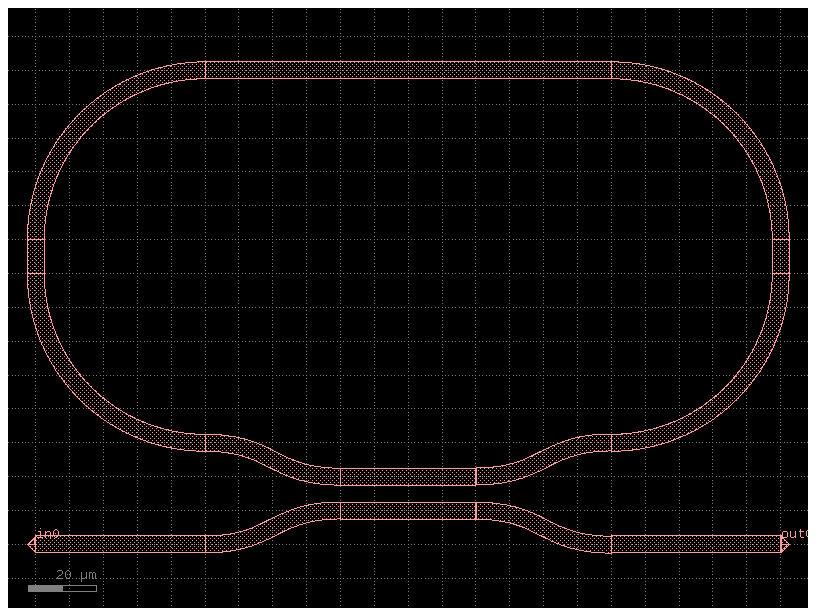

In [168]:
gf.clear_cache()
ring_ap = gf.Component()

wg_width = 5                    # Anchura de las guías de onda
acoplador_Lpi = 80              # Longitud Lpi del acoplador direccional 2x2
acoplador_wg_gap = 5            # Separación entre las dos guías del acoplador
recta_length_vertical = 10      # Longitud de las rectas verticales del anillo
codos90_radius = 50             # Radio de los codos circulares de 90 grados
recta_length_horizontal = 3*(acoplador_Lpi/2)

# Cross-section
xs = gf.cross_section.strip(width=wg_width, layer="WG")

# Creamos los componentes 
acoplador = acoplador2x2(wg_gap=acoplador_wg_gap, wg_width=wg_width, Lpi=acoplador_Lpi, xs=xs)
recta_vertical = gf.components.straight(length=recta_length_vertical, cross_section=xs)
codo90_subida = gf.components.bend_circular(radius=codos90_radius, angle=90, cross_section=xs)
recta_horizontal = gf.components.straight(length=recta_length_horizontal, cross_section=xs)
recta_in_out = gf.components.straight(length=codos90_radius, cross_section=xs)

# Añadimos los componentes
acoplador1 = ring_ap.add_ref(acoplador)
codo90_1 = ring_ap.add_ref(codo90_subida)
recta_vertical_1 = ring_ap.add_ref(recta_vertical)
codo90_2 = ring_ap.add_ref(codo90_subida)
recta_horizontal1 = ring_ap.add_ref(recta_horizontal)
codo90_3 = ring_ap.add_ref(codo90_subida)
recta_vertical_2 = ring_ap.add_ref(recta_vertical)
codo90_4 = ring_ap.add_ref(codo90_subida)
recta_in_out1 = ring_ap.add_ref(recta_in_out)
recta_in_out2 = ring_ap.add_ref(recta_in_out)

# Realizamos las conexiones
codo90_1.connect("o1", acoplador1.ports["out0"])
recta_vertical_1.connect("o1", codo90_1.ports["o2"])
codo90_2.connect("o1", recta_vertical_1.ports["o2"])
recta_horizontal1.connect("o1", codo90_2.ports["o2"])
codo90_3.connect("o1", recta_horizontal1.ports["o2"])
recta_vertical_2.connect("o1", codo90_3.ports["o2"])
codo90_4.connect("o1", recta_vertical_2.ports["o2"])
recta_in_out1.connect("o2", acoplador1.ports["in1"])
recta_in_out2.connect("o1", acoplador1.ports["out1"])

# Puertos exteriores
ring_ap.add_port("in0", port=recta_in_out1.ports["o1"])
ring_ap.add_port("out0", port=recta_in_out2.ports["o2"])

# Visualización
ring_ap.pprint_ports()
ring_ap.draw_ports()
ring_ap.plot()

In [13]:
# @gf.cell
# def ring_ap(wg_width, acoplador_Lpi, acoplador_wg_gap, recta_length_vertical, codos90_radius, recta_length_horizontal, xs):
#     ring_ap = gf.Component()

#     # Creamos los componentes 
#     acoplador = acoplador2x2(wg_gap=acoplador_wg_gap, wg_width=wg_width, Lpi=acoplador_Lpi, xs=xs)
#     recta_vertical = gf.components.straight(length=recta_length_vertical, cross_section=xs)
#     codo90_subida = gf.components.bend_circular(radius=codos90_radius, angle=90, cross_section=xs)
#     recta_horizontal = gf.components.straight(length=recta_length_horizontal, cross_section=xs)
#     recta_in_out = gf.components.straight(length=codos90_radius, cross_section=xs)

#     # Añadimos los componentes
#     acoplador1 = ring_ap.add_ref(acoplador)
#     codo90_1 = ring_ap.add_ref(codo90_subida)
#     recta_vertical_1 = ring_ap.add_ref(recta_vertical)
#     codo90_2 = ring_ap.add_ref(codo90_subida)
#     recta_horizontal1 = ring_ap.add_ref(recta_horizontal)
#     codo90_3 = ring_ap.add_ref(codo90_subida)
#     recta_vertical_2 = ring_ap.add_ref(recta_vertical)
#     codo90_4 = ring_ap.add_ref(codo90_subida)
#     recta_in_out1 = ring_ap.add_ref(recta_in_out)
#     recta_in_out2 = ring_ap.add_ref(recta_in_out)

#     # Realizamos las conexiones
#     codo90_1.connect("o1", acoplador1.ports["out0"])
#     recta_vertical_1.connect("o1", codo90_1.ports["o2"])
#     codo90_2.connect("o1", recta_vertical_1.ports["o2"])
#     recta_horizontal1.connect("o1", codo90_2.ports["o2"])
#     codo90_3.connect("o1", recta_horizontal1.ports["o2"])
#     recta_vertical_2.connect("o1", codo90_3.ports["o2"])
#     codo90_4.connect("o1", recta_vertical_2.ports["o2"])
#     recta_in_out1.connect("o2", acoplador1.ports["in1"])
#     recta_in_out2.connect("o1", acoplador1.ports["out1"])

#     # Puertos exteriores
#     ring_ap.add_port("in0", port=recta_in_out1.ports["o1"])
#     ring_ap.add_port("out0", port=recta_in_out2.ports["o2"])

#     return ring_ap

# gf.clear_cache()

# wg_width = 5                    # Anchura de las guías de onda
# acoplador_Lpi = 80              # Longitud Lpi del acoplador direccional 2x2
# acoplador_wg_gap = 5            # Separación entre las dos guías del acoplador
# recta_length_vertical = 10      # Longitud de las rectas verticales del anillo
# codos90_radius = 50             # Radio de los codos circulares de 90 grados
# recta_length_horizontal = 3*(acoplador_Lpi/2)

# # Cross-section
# xs = gf.cross_section.strip(width=wg_width, layer="WG")

# ring = ring_ap(wg_width, acoplador_Lpi, acoplador_wg_gap, recta_length_vertical, codos90_radius, recta_length_horizontal, xs)

# # Visualización
# ring.pprint_ports()
# ring.draw_ports()
# ring.plot()

## 2. Layout Fundamentals

A cell is a function that returns a Component. In GDS each component must have a unique name. Two components stored in the GDS file cannot have the same name. They need to be references (instances) of the same component.

![GDSFactoryComponents][def]


[def]: https://i.imgur.com/oeuKGsc.png

Let's build a Component from scratch. A die (chip) for a photonic layout. The PDK or Design Manual should specify the Layer for the bounding box (dicing line). 
We should also consider: 
1. The die dimensions and 
2. The border for dicing 

In [14]:
# wgw = 0.5
# dieL = 5000
# dieW = 5000
# border = 125
# layer_wg = "WG"
# layer_box = "FLOORPLAN"

# # Die specifications (Chip)
# box = gf.Component()

# obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
# ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
# box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# # Adding ports to a component 
# box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

# box.draw_ports()
# box.show()
# box.plot()

### Mantra: 
Once that we have a working 'new' component, we shall convert it into a Cell. This will allow us to have a hierarchical design

### Ejemplo

2026-06-12 14:48:43.198 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


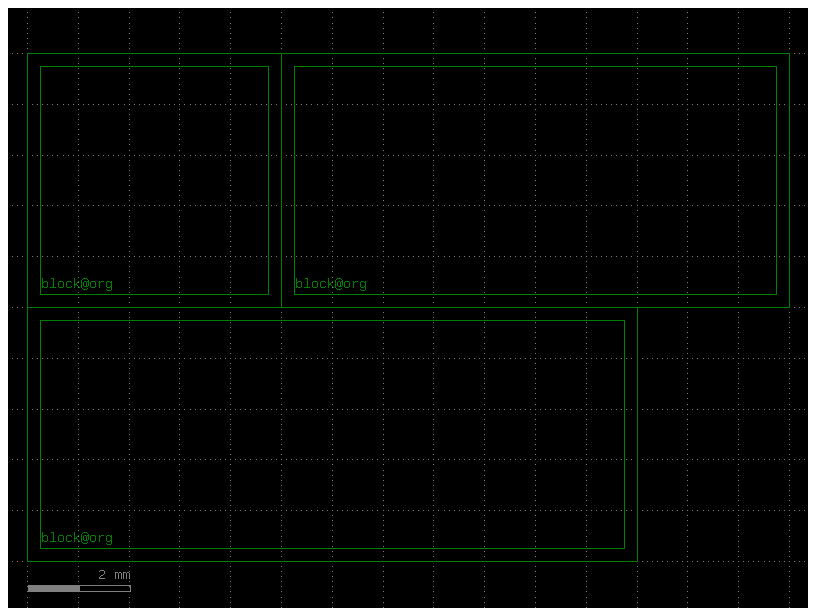

In [15]:
@gf.cell
def die(dieL=5000, dieW=5000, border=250, layer_box="FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW, dieL), layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2, dieL-border*2), layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)

    # Adding ports to a component 
    box.add_port(name="block@org", center=[border, border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

gf.clear_cache()

wafer = gf.Component()
dieW1 = 5000
dieW2 = 10000

c1 = wafer.add_ref(die(dieW=dieW1))
c2 = wafer.add_ref(die(dieW=dieW2))
c3 = wafer.add_ref(die(dieW=12000))

c2.dmovex(dieW1)
c3.dmovey(-5000)

wafer.show()
wafer.plot()

### DC

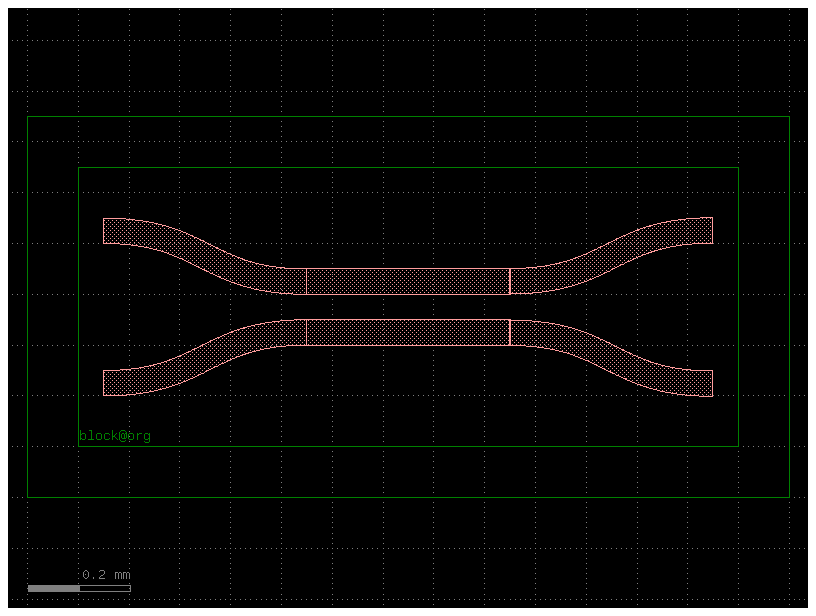

In [16]:
gf.clear_cache()

@gf.cell
def acoplador2x2(wg_gap, wg_width, Lpi, xs): 
    length = Lpi / 2
    
    acoplador = gf.Component()

    # Creamos los componentes
    recta = gf.components.straight(length=length, cross_section=xs)
    codo_arriba = gf.components.bend_s(size=(length, (wg_gap + wg_width)), cross_section=xs)
    codo_abajo = gf.components.bend_s(size=(length, -(wg_gap + wg_width)), cross_section=xs)

    # Añadimos los cuatros codos
    codoSW = acoplador.add_ref(codo_arriba)
    codoNW = acoplador.add_ref(codo_abajo)
    codoSE = acoplador.add_ref(codo_abajo)
    codoNE = acoplador.add_ref(codo_arriba)

    # Añadimos las dos rectas
    rectaN = acoplador.add_ref(recta)
    rectaS = acoplador.add_ref(recta)

    # Movemos y conectamos
    rectaN.movey(wg_gap + wg_width)
    codoSW.connect("o2", rectaS.ports["o1"])
    codoNW.connect("o2", rectaN.ports["o1"])
    codoSE.connect("o1", rectaS.ports["o2"])
    codoNE.connect("o1", rectaN.ports["o2"])

    # Puertos exteriores:
    acoplador.add_port("in1", port=codoSW.ports["o1"])
    acoplador.add_port("in0", port=codoNW.ports["o1"])
    acoplador.add_port("out1", port=codoSE.ports["o2"])
    acoplador.add_port("out0", port=codoNE.ports["o2"])
    return acoplador

xs = gf.cross_section.strip(width=50, layer="WG")

layout_acoplador = gf.Component()

die1 = layout_acoplador.add_ref(die(dieL=750, dieW=1500, border=100, layer_box="FLOORPLAN"))
acoplador1 = layout_acoplador.add_ref(acoplador2x2(wg_gap=50, wg_width=50, Lpi=800, xs=xs))

acoplador1.dcenter = die1.dcenter

layout_acoplador.plot()

### MMI

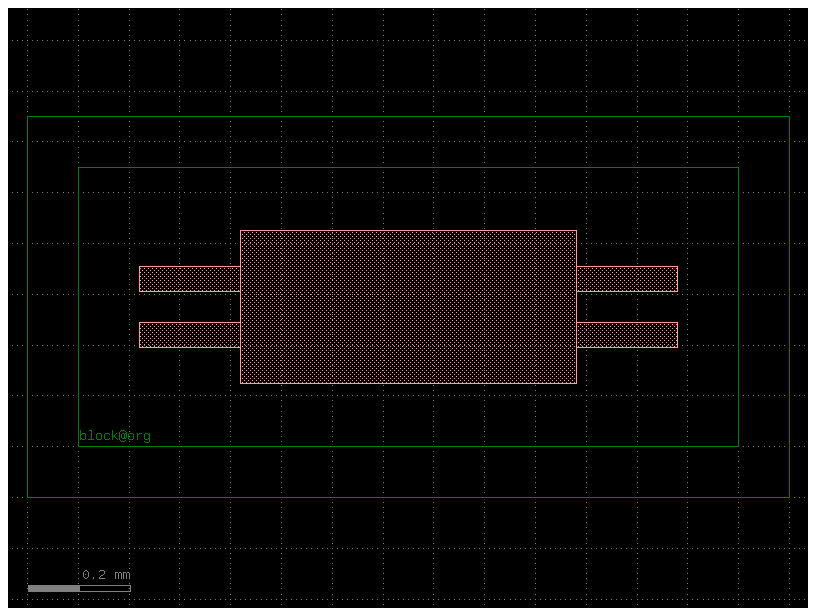

In [17]:
gf.clear_cache()

@gf.cell
def mmi2x2(mmi_Width, length, Lpi, dy, dL_MMI, xs):
    L_MMI = (1/2)*Lpi - dL_MMI
    IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])
    OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])

    mmi = gf.Component()
    
    # Creamos los componentes
    rectangulo = gf.components.rectangle(size=(L_MMI, mmi_Width), layer="WG")
    recta = gf.components.straight(length=length, cross_section=xs)

    # Añadimos rectangulo central
    rectanguloCentral = mmi.add_ref(rectangulo)

    # Añadimos las cuatro rectas entrada y salida
    recta1 = mmi.add_ref(recta)
    recta2 = mmi.add_ref(recta)
    recta3 = mmi.add_ref(recta)
    recta4 = mmi.add_ref(recta)

    # Movemos rectas in
    recta1.movex(-length)
    recta2.movex(-length)
    recta1.movey(IN_WVG_positions[1])
    recta2.movey(IN_WVG_positions[0])

    # Movemos rectangulo
    rectanguloCentral.movey(-mmi_Width / 2)

    # Movemos rectas out
    recta3.movex(L_MMI)
    recta4.movex(L_MMI)
    recta3.movey(OUT_WVG_positions[1])
    recta4.movey(OUT_WVG_positions[0])

    # Puertos exteriores:
    mmi.add_port("in0", port=recta1.ports["o1"])
    mmi.add_port("in1", port=recta2.ports["o1"])
    mmi.add_port("out0", port=recta3.ports["o2"])
    mmi.add_port("out1", port=recta4.ports["o2"])
    
    return mmi

layout_mmi = gf.Component()

die1 = layout_mmi.add_ref(die(dieL=750, dieW=1500, border=100, layer_box="FLOORPLAN"))

# Cross-section
xs = gf.cross_section.strip(width=50, layer="WG")

mmi1 = layout_mmi.add_ref(mmi2x2(mmi_Width=300, length=200, Lpi=1300, dy=5, dL_MMI=-10, xs = xs))

mmi1.center = die1.center

layout_mmi.plot()

### MZI

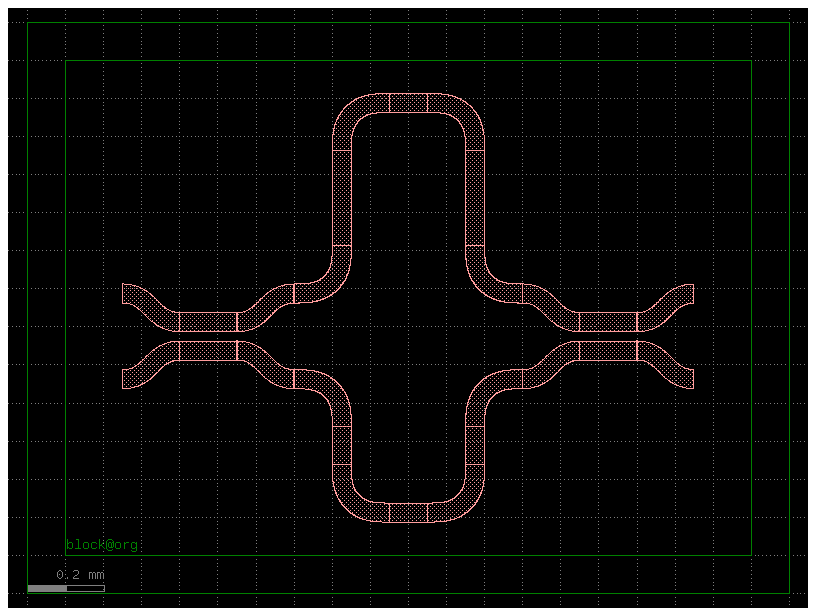

In [18]:
gf.clear_cache()

@gf.cell
def mzi(wg_width, acoplador_Lpi, acoplador_wg_gap, recta_length_verticalN, recta_length_verticalS, recta_length_horizontal, 
        xs, codos90_radius): 
    mzi = gf.Component()

    # Creamos los componentes 
    acoplador = acoplador2x2(acoplador_wg_gap, wg_width=wg_width, Lpi=acoplador_Lpi, xs=xs)
    recta_verticalN = gf.components.straight(length=recta_length_verticalN, cross_section=xs)
    recta_verticalS = gf.components.straight(length=recta_length_verticalS, cross_section=xs)
    recta_horizontal = gf.components.straight(length=recta_length_horizontal, cross_section=xs)
    codo90_subida = gf.components.bend_euler(radius=codos90_radius, angle=90, cross_section=xs)
    codo90_bajada = gf.components.bend_euler(radius=codos90_radius, angle=-90, cross_section=xs)

    # Añadimos los componentes
    acopladorW = mzi.add_ref(acoplador)
    codo90_1 = mzi.add_ref(codo90_subida)
    recta_vertical1 = mzi.add_ref(recta_verticalN)
    codo90_2 = mzi.add_ref(codo90_bajada)
    recta_horizontalN = mzi.add_ref(recta_horizontal)
    codo90_3 = mzi.add_ref(codo90_bajada)
    recta_vertical2 = mzi.add_ref(recta_verticalN)
    codo90_4 = mzi.add_ref(codo90_subida)

    acopladorE = mzi.add_ref(acoplador)
    codo90_5 = mzi.add_ref(codo90_subida)
    recta_vertical3 = mzi.add_ref(recta_verticalS)
    codo90_6 = mzi.add_ref(codo90_bajada)
    recta_horizontalS = mzi.add_ref(recta_horizontal)
    codo90_7 = mzi.add_ref(codo90_bajada)
    recta_vertical4 = mzi.add_ref(recta_verticalS)
    codo90_8 = mzi.add_ref(codo90_subida)

    # Realizamos las conexiones
    acopladorW.connect("out0", codo90_1.ports["o1"])
    recta_vertical1.connect("o1", codo90_1.ports["o2"])
    codo90_2.connect("o1", recta_vertical1.ports["o2"])
    recta_horizontalN.connect("o1", codo90_2.ports["o2"])
    codo90_3.connect("o1", recta_horizontalN.ports["o2"])
    recta_vertical2.connect("o1", codo90_3.ports["o2"])
    codo90_4.connect("o1", recta_vertical2.ports["o2"])

    acopladorE.connect("in0", codo90_4.ports["o2"])
    codo90_5.connect("o1", acopladorE.ports["in1"])
    recta_vertical3.connect("o1", codo90_5.ports["o2"])
    codo90_6.connect("o1", recta_vertical3.ports["o2"])
    recta_horizontalS.connect("o1", codo90_6.ports["o2"])
    codo90_7.connect("o1", recta_horizontalS.ports["o2"])
    recta_vertical4.connect("o1", codo90_7.ports["o2"])
    codo90_8.connect("o1", recta_vertical4.ports["o2"])

    # Puertos exteriores
    mzi.add_port("in0", port=acopladorW.ports["in0"])
    mzi.add_port("in1", port=acopladorW.ports["in1"])
    mzi.add_port("out0", port=acopladorE.ports["out0"])
    mzi.add_port("out1", port=acopladorE.ports["out1"])
    return mzi


# Cross-section
xs = gf.cross_section.strip(width=50, layer="WG")

layout_mzi = gf.Component()

die_ref = layout_mzi.add_ref(die(dieL=1500, dieW=2000, border=100, layer_box="FLOORPLAN"))
mzi_ref = layout_mzi.add_ref(mzi(wg_width=25, acoplador_Lpi=300, acoplador_wg_gap=50, recta_length_verticalN=250, 
                                 recta_length_verticalS=100, recta_length_horizontal=100, xs=xs, codos90_radius=125))

mzi_ref.dcenter = die_ref.dcenter

layout_mzi.plot()

### Ring Resonator

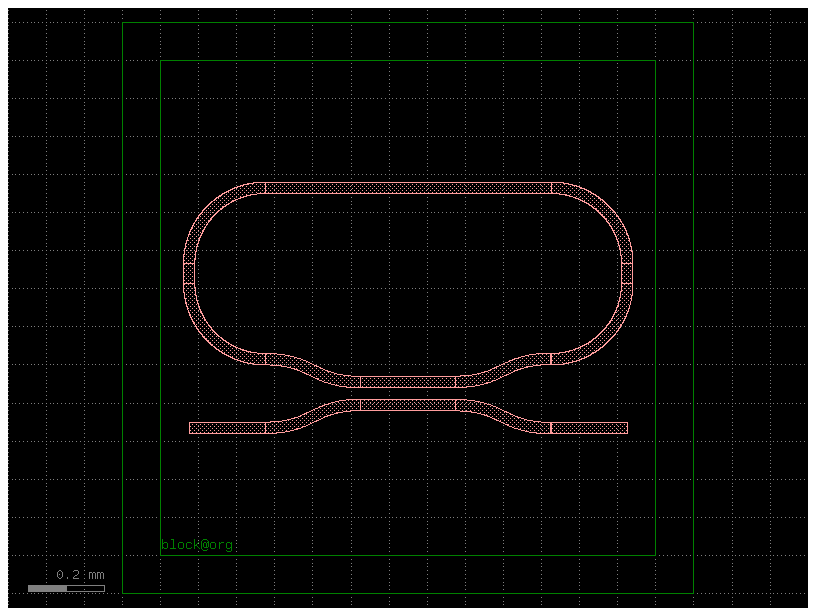

In [19]:
gf.clear_cache()

@gf.cell
def ring_ap(wg_width, acoplador_Lpi, acoplador_wg_gap, recta_length_vertical, codos90_radius, xs):
    recta_length_horizontal = 3*(acoplador_Lpi/2)
    ring_ap = gf.Component()

    # Creamos los componentes 
    acoplador = acoplador2x2(wg_gap=acoplador_wg_gap, wg_width=wg_width, Lpi=acoplador_Lpi, xs=xs)
    recta_vertical = gf.components.straight(length=recta_length_vertical, cross_section=xs)
    codo90_subida = gf.components.bend_circular(radius=codos90_radius, angle=90, cross_section=xs)
    recta_horizontal = gf.components.straight(length=recta_length_horizontal, cross_section=xs)
    recta_in_out = gf.components.straight(length=codos90_radius, cross_section=xs)

    # Añadimos los componentes
    acoplador1 = ring_ap.add_ref(acoplador)
    codo90_1 = ring_ap.add_ref(codo90_subida)
    recta_vertical_1 = ring_ap.add_ref(recta_vertical)
    codo90_2 = ring_ap.add_ref(codo90_subida)
    recta_horizontal1 = ring_ap.add_ref(recta_horizontal)
    codo90_3 = ring_ap.add_ref(codo90_subida)
    recta_vertical_2 = ring_ap.add_ref(recta_vertical)
    codo90_4 = ring_ap.add_ref(codo90_subida)
    recta_in_out1 = ring_ap.add_ref(recta_in_out)
    recta_in_out2 = ring_ap.add_ref(recta_in_out)

    # Realizamos las conexiones
    codo90_1.connect("o1", acoplador1.ports["out0"])
    recta_vertical_1.connect("o1", codo90_1.ports["o2"])
    codo90_2.connect("o1", recta_vertical_1.ports["o2"])
    recta_horizontal1.connect("o1", codo90_2.ports["o2"])
    codo90_3.connect("o1", recta_horizontal1.ports["o2"])
    recta_vertical_2.connect("o1", codo90_3.ports["o2"])
    codo90_4.connect("o1", recta_vertical_2.ports["o2"])
    recta_in_out1.connect("o2", acoplador1.ports["in1"])
    recta_in_out2.connect("o1", acoplador1.ports["out1"])

    # Puertos exteriores
    ring_ap.add_port("in0", port=recta_in_out1.ports["o1"])
    ring_ap.add_port("out0", port=recta_in_out2.ports["o2"])

    return ring_ap

# Cross-section
xs = gf.cross_section.strip(width=30, layer="WG")

layout_ring = gf.Component()

die1 = layout_ring.add_ref(die(dieL=1500, dieW=1500, border=100, layer_box="FLOORPLAN"))
ring1 = layout_ring.add_ref(ring_ap(wg_width=30, acoplador_Lpi=500, acoplador_wg_gap=30, recta_length_vertical=50, codos90_radius=200, xs=xs))

ring1.dcenter = die1.dcenter

layout_ring.plot()

## 3. Complete Layout

2026-06-12 14:48:43.818 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


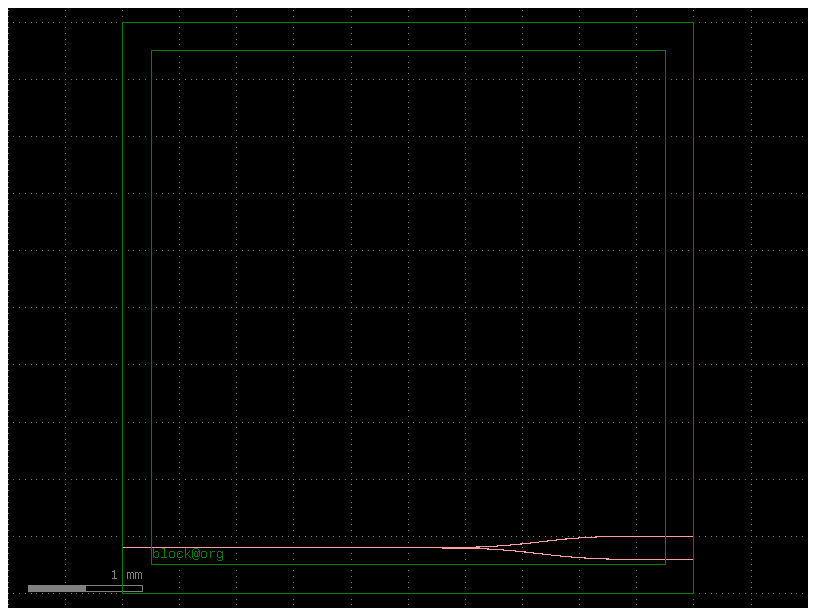

In [20]:
layer_wg  = "WG"
minrad = 50
dieW = 5000

main = gf.Component()

die_ref = main.add_ref(die(dieW = dieW, layer_box="FLOORPLAN"))

## Add first a test MMI routed from side to side
c_mmi = cells.mmi1x2()
mmi = main.add_ref(c_mmi)
mmi.dmovex(die_ref["block@org"].dx + 0.5*dieW).dmovey(die_ref['block@org'].dy + 150)

## Route waveguides from MMI to the die edges
xs = 'strip'
### First add the i/o waveguides - to be sure you 'cut' on a straight section
strin = (main.add_ref(gf.components.straight(length=500, cross_section='strip')).dmovex(0).dmovey(mmi['o1'].dy))
strout1 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o3'].dy-100).dmovex(dieW))
strout2 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o2'].dy+100).dmovex(dieW))
### Then route from the i/o waveguides to the MMI
gf.routing.route_single_sbend(main,port1=strin['o2'], port2=mmi['o1'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o2'], port2=strout2['o2'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o3'], port2=strout1['o2'], cross_section=xs)

main.plot()
main.show()

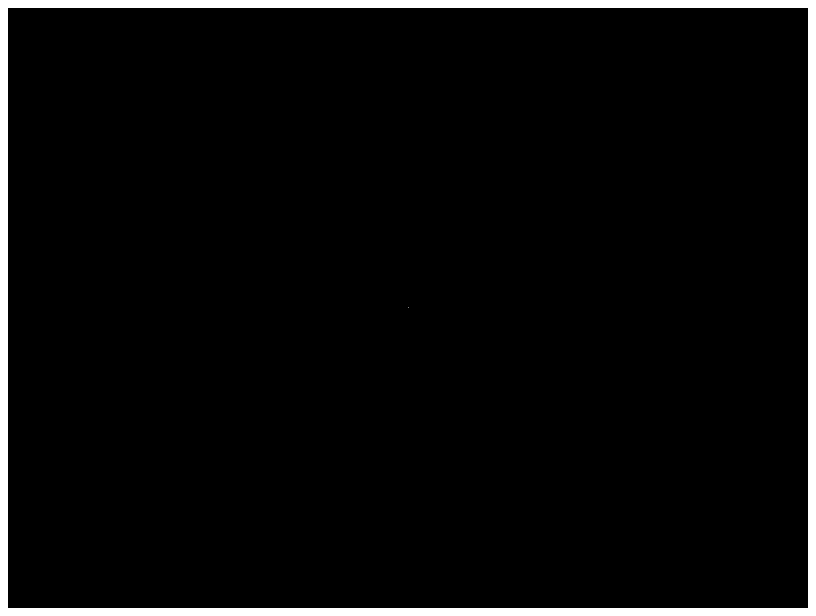

In [21]:
# Let's create a MMI tree

c = gf.Component()
c_mmi = cells.mmi1x2()
...
c.plot()

In [22]:
# Once we "test" the high-level component, we can create a cell for it
@gf.cell 
def mmi_tree_1x4(pad_x = 250 ,pad_y = 250):
    c = gf.Component()
    c_mmi = cells.mmi1x2()
    mmi1 = c.add_ref(c_mmi)
    mmi2 = c.add_ref(c_mmi)
    mmi3 = c.add_ref(c_mmi)

    mmi2.dmovex(pad_x).dmovey(pad_y)
    mmi3.dmovex(pad_x).dmovey(-pad_y)

    gf.routing.route_single_sbend(component=c, port1= mmi1['o2'], port2=mmi2['o1'],cross_section='strip')
    gf.routing.route_single_sbend(component=c, port1= mmi1['o3'], port2=mmi3['o1'],cross_section='strip')
    c.add_port(name='o1', port=mmi1['o1'])
    c.add_port(name='o2', port=mmi2['o2'])
    c.add_port(name='o3', port=mmi2['o3'])
    c.add_port(name='o4', port=mmi3['o2'])
    c.add_port(name='o5', port=mmi3['o3'])
    c.draw_ports()
    return c

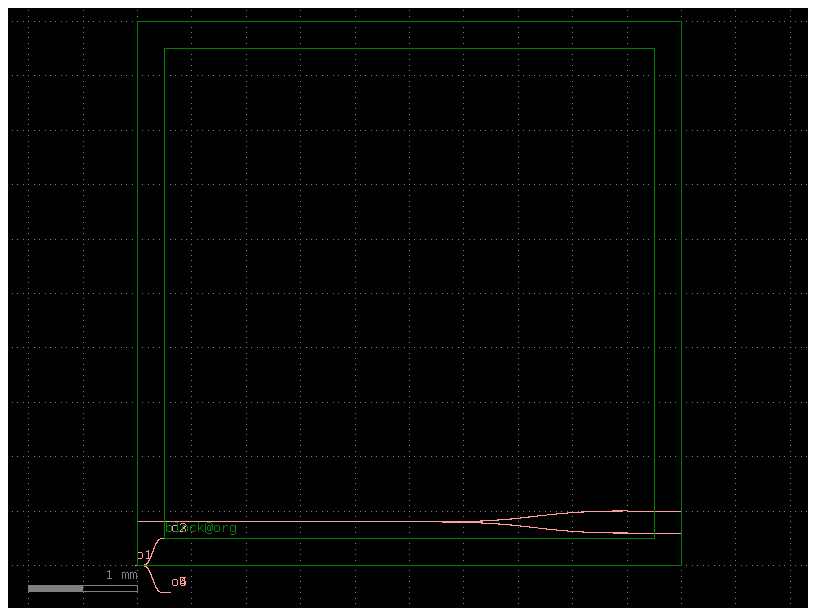

In [23]:
# With the cell created, we can instantiate and use it in our main component

cell_1x4 = main.add_ref(mmi_tree_1x4())
main.plot()


2026-06-12 14:48:44.142 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


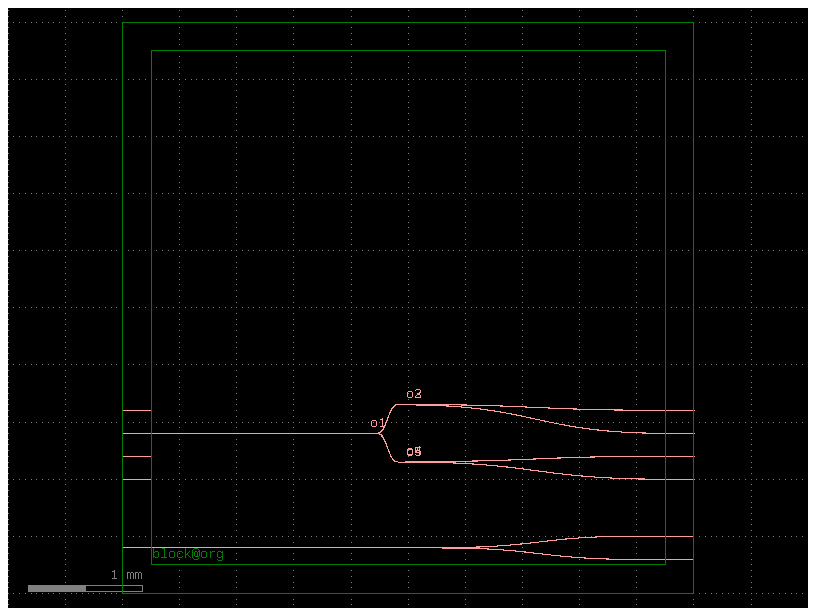

In [24]:
## Arrayed waveguides and MMI tree

sp = 200
border = 250

in_arr = main.add_ref(
    gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
).dmovey(
    1000
)  #!!!!!! Easy to put IO Waveguides for a complete design !!!!

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)

cell_1x4.dmovex(0.5*dieW - mmi_tree_1x4().dxsize).dmovey(in_arr['o6'].dy)
gf.routing.route_single_sbend(component=main, port1=in_arr['o6'], port2=cell_1x4['o1'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o2'], port2=out_arr['o4'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o3'], port2=out_arr['o3'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o4'], port2=out_arr['o2'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o5'], port2=out_arr['o1'])
main.plot()
main.show()

### Mantra:
It's useful to use memorize this mantra: 
- Add_references 
- Connect_them
- Move_them

### Other Routing options examples:

Please check the GDSFactory Routing API for more information about advanced routing functionalities

[Routing API](https://gdsfactory.github.io/gdsfactory/api_routing.html) 

## 4. Exercises. 

Part a) Creating components
- Create a cell component for a unbalanced MZI, using 2x2 50:50 MMIs with arm length difference as parameter
- Create a cell component based on the previous, where the arms have thermal tuners on top of each one
- Create a cell component for an all-pass ring resonator, using 2x2 50:50 MMIs, with extra length parameter for different perimeters
- Create a cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter
- Create a cell component based on existing GDSfactory spiral components, with length as parameter

Part b) Creating die
- Create a die  W = 5 mm x L = 10 mm 
- Create an array of I/Os spaced at 250 µm (as much I/Os as the width allows)
- Create a cell component of this die, with I/Os accessible to connect

Part c) Floorplaning and die layout
- Make an instance of the die as host component for your layout
- Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die
- Add 2 of each of the components above, with different lengths
- Connect all your components to the I/Os 

### a) Creating Components

#### a1) Create a cell component for a unbalanced MZI, using 2x2 50:50 MMIs with arm length difference as parameter

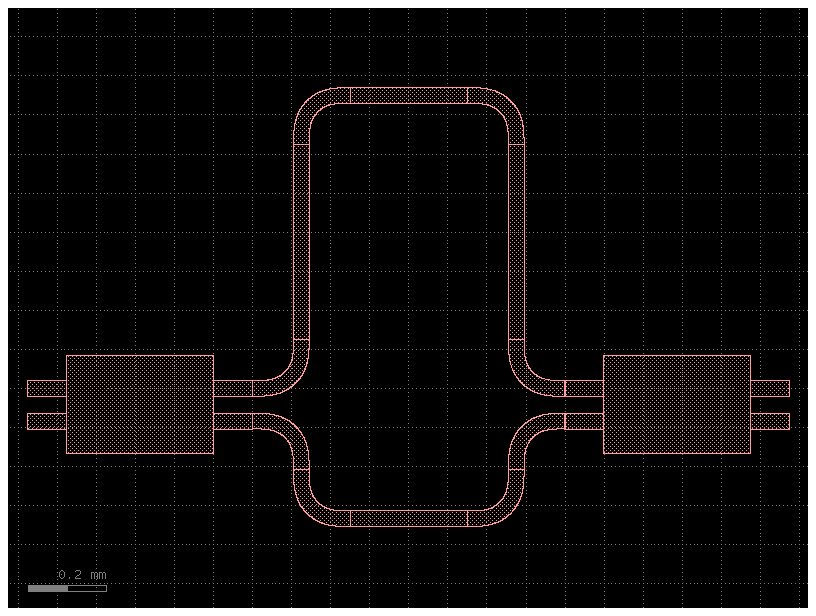

In [25]:
gf.clear_cache()

@gf.cell
def mzi(mmi_Lpi, mmi_Width, mmi_recta_length, dL, recta_length_horizontal, xs, codos90_radius, mmi_dy=0, mmi_dL=0): 
    mzi = gf.Component()

    # Creamos los componentes 
    mmi = mmi2x2(Lpi = mmi_Lpi, mmi_Width = mmi_Width, length=mmi_recta_length, dy=mmi_dy, dL_MMI=mmi_dL, xs = xs)
    recta_verticalN = gf.components.straight(length=dL, cross_section=xs)
    recta_verticalS = gf.components.straight(length=0, cross_section=xs)
    recta_horizontal = gf.components.straight(length=recta_length_horizontal, cross_section=xs)
    codo90_subida = gf.components.bend_euler(radius=codos90_radius, angle=90, cross_section=xs)
    codo90_bajada = gf.components.bend_euler(radius=codos90_radius, angle=-90, cross_section=xs)

    # Añadimos los componentes
    mmiW = mzi.add_ref(mmi)
    codo90_1 = mzi.add_ref(codo90_subida)
    recta_vertical1 = mzi.add_ref(recta_verticalN)
    codo90_2 = mzi.add_ref(codo90_bajada)
    recta_horizontalN = mzi.add_ref(recta_horizontal)
    codo90_3 = mzi.add_ref(codo90_bajada)
    recta_vertical2 = mzi.add_ref(recta_verticalN)
    codo90_4 = mzi.add_ref(codo90_subida)

    mmiE = mzi.add_ref(mmi)
    codo90_5 = mzi.add_ref(codo90_subida)
    recta_vertical3 = mzi.add_ref(recta_verticalS)
    codo90_6 = mzi.add_ref(codo90_bajada)
    recta_horizontalS = mzi.add_ref(recta_horizontal)
    codo90_7 = mzi.add_ref(codo90_bajada)
    recta_vertical4 = mzi.add_ref(recta_verticalS)
    codo90_8 = mzi.add_ref(codo90_subida)

    # Realizamos las conexiones
    mmiW.connect("out0", codo90_1.ports["o1"])
    recta_vertical1.connect("o1", codo90_1.ports["o2"])
    codo90_2.connect("o1", recta_vertical1.ports["o2"])
    recta_horizontalN.connect("o1", codo90_2.ports["o2"])
    codo90_3.connect("o1", recta_horizontalN.ports["o2"])
    recta_vertical2.connect("o1", codo90_3.ports["o2"])
    codo90_4.connect("o1", recta_vertical2.ports["o2"])

    mmiE.connect("in0", codo90_4.ports["o2"])
    codo90_5.connect("o1", mmiE.ports["in1"])
    recta_vertical3.connect("o1", codo90_5.ports["o2"])
    codo90_6.connect("o1", recta_vertical3.ports["o2"])
    recta_horizontalS.connect("o1", codo90_6.ports["o2"])
    codo90_7.connect("o1", recta_horizontalS.ports["o2"])
    recta_vertical4.connect("o1", codo90_7.ports["o2"])
    codo90_8.connect("o1", recta_vertical4.ports["o2"])

    # Puertos exteriores
    mzi.add_port("in0", port=mmiW.ports["in0"])
    mzi.add_port("in1", port=mmiW.ports["in1"])
    mzi.add_port("out0", port=mmiE.ports["out0"])
    mzi.add_port("out1", port=mmiE.ports["out1"])
    return mzi

# Cross-section
xs = gf.cross_section.strip(width=40, layer="WG")

mzi1 = mzi(dL=500, mmi_Lpi = 750, mmi_Width=250, mmi_recta_length=100, recta_length_horizontal=300, xs=xs, codos90_radius=125)

mzi1.plot()

#### a2) Create a cell component based on the previous, where the arms have thermal tuners on top of each one

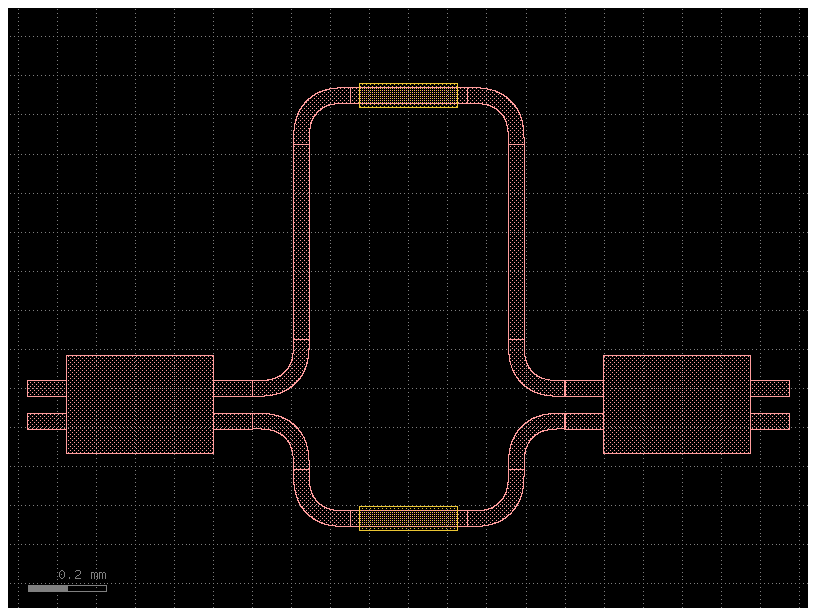

In [26]:
gf.clear_cache()

@gf.cell
def mzi_thermal(mmi_Lpi, mmi_Width, mmi_recta_length, dL, recta_length_horizontal, xs, codos90_radius, heater_width, heater_length, layer_heater, mmi_dy=0, mmi_dL=0): 
    mzi = gf.Component()

    # Creamos los componentes 
    mmi_cell = mmi2x2(Lpi=mmi_Lpi, mmi_Width=mmi_Width, length=mmi_recta_length, dy=mmi_dy, dL_MMI=mmi_dL, xs=xs)
    recta_verticalN = gf.components.straight(length=dL, cross_section=xs)
    recta_verticalS = gf.components.straight(length=0, cross_section=xs)
    recta_horizontal = gf.components.straight(length=recta_length_horizontal, cross_section=xs)
    codo90_subida = gf.components.bend_euler(radius=codos90_radius, angle=90, cross_section=xs)
    codo90_bajada = gf.components.bend_euler(radius=codos90_radius, angle=-90, cross_section=xs)
    heater = gf.components.rectangle(size=(heater_length, heater_width), layer=layer_heater)

    # Añadimos los componentes
    mmiW = mzi.add_ref(mmi_cell)
    codo90_1 = mzi.add_ref(codo90_subida)
    recta_vertical1 = mzi.add_ref(recta_verticalN)
    codo90_2 = mzi.add_ref(codo90_bajada)
    recta_horizontalN = mzi.add_ref(recta_horizontal)
    codo90_3 = mzi.add_ref(codo90_bajada)
    recta_vertical2 = mzi.add_ref(recta_verticalN)
    codo90_4 = mzi.add_ref(codo90_subida)

    mmiE = mzi.add_ref(mmi_cell)
    codo90_5 = mzi.add_ref(codo90_subida)
    recta_vertical3 = mzi.add_ref(recta_verticalS)
    codo90_6 = mzi.add_ref(codo90_bajada)
    recta_horizontalS = mzi.add_ref(recta_horizontal)
    codo90_7 = mzi.add_ref(codo90_bajada)
    recta_vertical4 = mzi.add_ref(recta_verticalS)
    codo90_8 = mzi.add_ref(codo90_subida)

    # Realizamos las conexiones
    mmiW.connect("out0", codo90_1.ports["o1"])
    recta_vertical1.connect("o1", codo90_1.ports["o2"])
    codo90_2.connect("o1", recta_vertical1.ports["o2"])
    recta_horizontalN.connect("o1", codo90_2.ports["o2"])
    codo90_3.connect("o1", recta_horizontalN.ports["o2"])
    recta_vertical2.connect("o1", codo90_3.ports["o2"])
    codo90_4.connect("o1", recta_vertical2.ports["o2"])

    mmiE.connect("in0", codo90_4.ports["o2"])
    codo90_5.connect("o1", mmiE.ports["in1"])
    recta_vertical3.connect("o1", codo90_5.ports["o2"])
    codo90_6.connect("o1", recta_vertical3.ports["o2"])
    recta_horizontalS.connect("o1", codo90_6.ports["o2"])
    codo90_7.connect("o1", recta_horizontalS.ports["o2"])
    recta_vertical4.connect("o1", codo90_7.ports["o2"])
    codo90_8.connect("o1", recta_vertical4.ports["o2"])

    # Añadimos los thermal tuners encima de cada brazo
    heaterN = mzi.add_ref(heater)
    heaterS = mzi.add_ref(heater)

    heaterN.dcenter = recta_horizontalN.dcenter
    heaterS.dcenter = recta_horizontalS.dcenter

    # Puertos exteriores
    mzi.add_port("in0", port=mmiW.ports["in0"])
    mzi.add_port("in1", port=mmiW.ports["in1"])
    mzi.add_port("out0", port=mmiE.ports["out0"])
    mzi.add_port("out1", port=mmiE.ports["out1"])

    return mzi
# Cross-section
xs = gf.cross_section.strip(width=40, layer="WG")

mzi1 = mzi_thermal(dL=500, mmi_Lpi=750, mmi_Width=250, mmi_recta_length=100, recta_length_horizontal=300, xs=xs, codos90_radius=125, heater_width=60, heater_length=250, layer_heater="HEATER")
mzi1.plot()

#### a3) Create a cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter

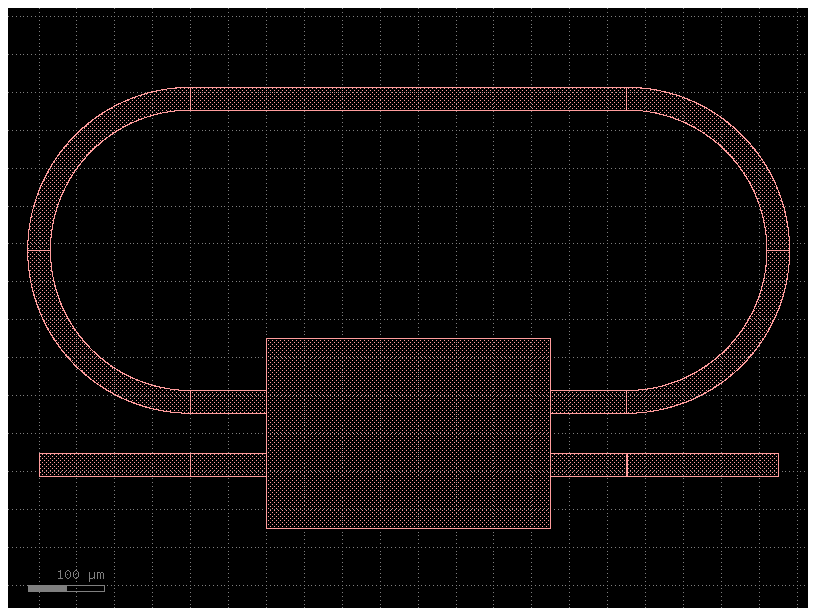

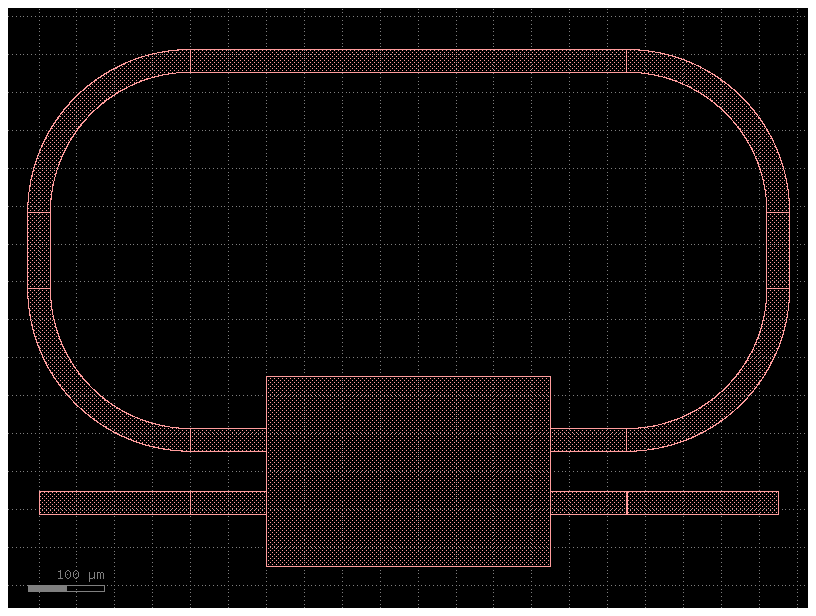

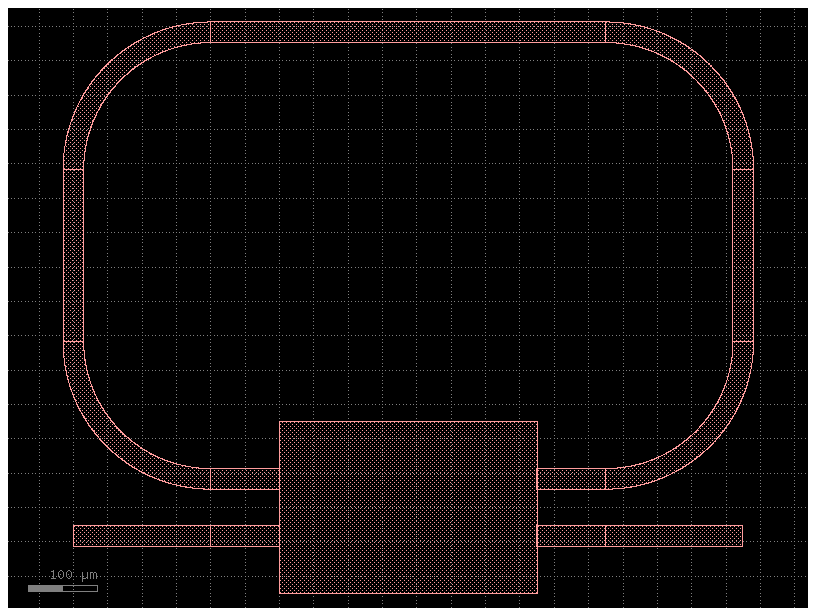

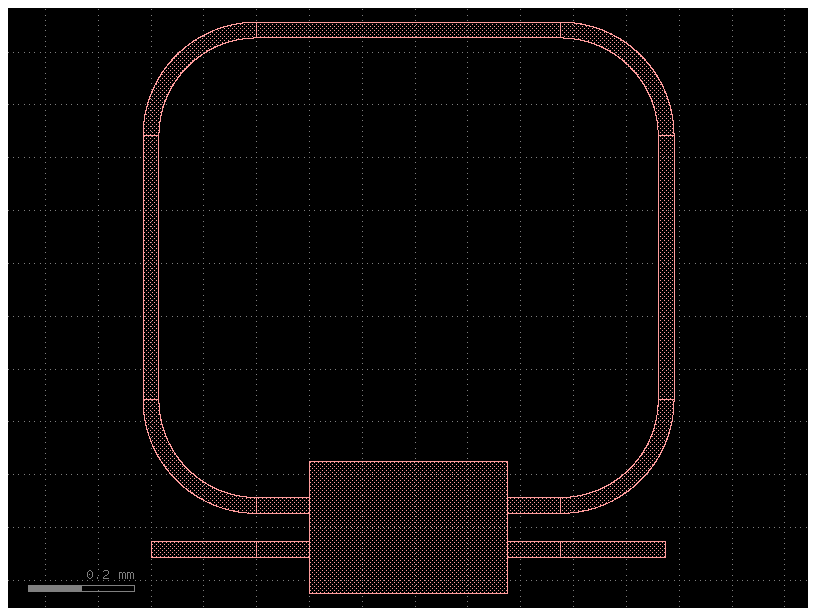

In [27]:
gf.clear_cache()

@gf.cell
def ring_ap_mmi(mmi_Lpi, mmi_Width, mmi_recta_length, extra_length, codos90_radius, xs, mmi_dy=0, mmi_dL=0):
    ring_ap = gf.Component()

    # Longitud total del MMI
    L_MMI = (1/2)*mmi_Lpi - mmi_dL
    recta_length_horizontal = 2*mmi_recta_length + L_MMI

    # Añadimos longitud extra al perímetro del anillo
    recta_length_vertical_total = extra_length / 2

    # Creamos los componentes 
    mmi_cell = mmi2x2(Lpi=mmi_Lpi, mmi_Width=mmi_Width, length=mmi_recta_length, dy=mmi_dy, dL_MMI=mmi_dL, xs=xs)
    recta_vertical = gf.components.straight(length=recta_length_vertical_total, cross_section=xs)
    codo90_subida = gf.components.bend_circular(radius=codos90_radius, angle=90, cross_section=xs)
    recta_horizontal = gf.components.straight(length=recta_length_horizontal, cross_section=xs)
    recta_in_out = gf.components.straight(length=codos90_radius, cross_section=xs)

    # Añadimos los componentes
    mmi1 = ring_ap.add_ref(mmi_cell)
    codo90_1 = ring_ap.add_ref(codo90_subida)
    recta_vertical_1 = ring_ap.add_ref(recta_vertical)
    codo90_2 = ring_ap.add_ref(codo90_subida)
    recta_horizontal1 = ring_ap.add_ref(recta_horizontal)
    codo90_3 = ring_ap.add_ref(codo90_subida)
    recta_vertical_2 = ring_ap.add_ref(recta_vertical)
    codo90_4 = ring_ap.add_ref(codo90_subida)
    recta_in_out1 = ring_ap.add_ref(recta_in_out)
    recta_in_out2 = ring_ap.add_ref(recta_in_out)

    # Realizamos las conexiones del anillo
    codo90_1.connect("o1", mmi1.ports["out0"])
    recta_vertical_1.connect("o1", codo90_1.ports["o2"])
    codo90_2.connect("o1", recta_vertical_1.ports["o2"])
    recta_horizontal1.connect("o1", codo90_2.ports["o2"])
    codo90_3.connect("o1", recta_horizontal1.ports["o2"])
    recta_vertical_2.connect("o1", codo90_3.ports["o2"])
    codo90_4.connect("o1", recta_vertical_2.ports["o2"])

    # Guías de entrada y salida
    recta_in_out1.connect("o2", mmi1.ports["in1"])
    recta_in_out2.connect("o1", mmi1.ports["out1"])

    # Puertos exteriores
    ring_ap.add_port("in0", port=recta_in_out1.ports["o1"])
    ring_ap.add_port("out0", port=recta_in_out2.ports["o2"])

    return ring_ap

# Cross-section
xs = gf.cross_section.strip(width=30, layer="WG")

ring1 = ring_ap_mmi(extra_length=0, mmi_Lpi=750, mmi_Width=250, mmi_recta_length=100, codos90_radius=200, xs=xs)
ring2 = ring_ap_mmi(extra_length=200, mmi_Lpi=750, mmi_Width=250, mmi_recta_length=100, xs=xs, codos90_radius=200)
ring3 = ring_ap_mmi(extra_length=500, mmi_Lpi=750, mmi_Width=250, mmi_recta_length=100, xs=xs, codos90_radius=200)

ring4 = ring_ap_mmi(extra_length=1000, mmi_Lpi=750, mmi_Width=250, mmi_recta_length=100, xs=xs, codos90_radius=200)

ring1.plot()
ring2.plot()
ring3.plot()
ring4.plot()

#### a4) Create a cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter

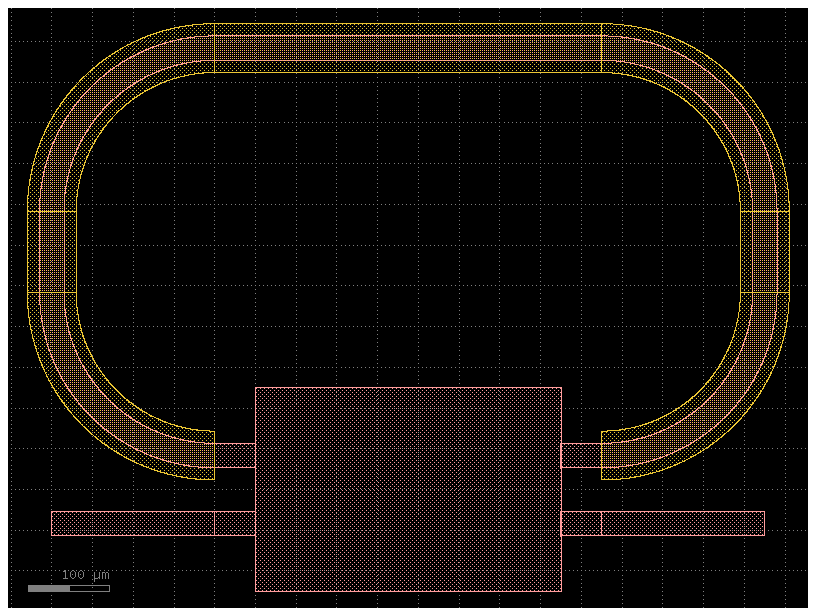

In [28]:
gf.clear_cache()

@gf.cell
def ring_ap_mmi_thermal(mmi_Lpi, mmi_Width, mmi_recta_length, extra_length, codos90_radius, xs, heater_width, layer_heater, mmi_dy=0, mmi_dL=0):
    ring_ap = gf.Component()

    # Longitud total del MMI
    L_MMI = (1/2)*mmi_Lpi - mmi_dL
    recta_length_horizontal = 2*mmi_recta_length + L_MMI

    # Añadimos longitud extra al perímetro del anillo
    recta_length_vertical_total = extra_length / 2

    # Creamos los componentes 
    mmi_cell = mmi2x2(Lpi=mmi_Lpi, mmi_Width=mmi_Width, length=mmi_recta_length, dy=mmi_dy, dL_MMI=mmi_dL, xs=xs)
    recta_vertical = gf.components.straight(length=recta_length_vertical_total, cross_section=xs)
    codo90_subida = gf.components.bend_circular(radius=codos90_radius, angle=90, cross_section=xs)
    recta_horizontal = gf.components.straight(length=recta_length_horizontal, cross_section=xs)
    recta_in_out = gf.components.straight(length=codos90_radius, cross_section=xs)

    # Creamos los componentes del heater
    xs_heater = gf.cross_section.strip(width=heater_width, layer=layer_heater)
    heater_recta_vertical = gf.components.straight(length=recta_length_vertical_total, cross_section=xs_heater)
    heater_codo90_subida = gf.components.bend_circular(radius=codos90_radius, angle=90, cross_section=xs_heater)
    heater_recta_horizontal = gf.components.straight(length=recta_length_horizontal, cross_section=xs_heater)

    # Añadimos los componentes
    mmi1 = ring_ap.add_ref(mmi_cell)
    codo90_1 = ring_ap.add_ref(codo90_subida)
    recta_vertical_1 = ring_ap.add_ref(recta_vertical)
    codo90_2 = ring_ap.add_ref(codo90_subida)
    recta_horizontal1 = ring_ap.add_ref(recta_horizontal)
    codo90_3 = ring_ap.add_ref(codo90_subida)
    recta_vertical_2 = ring_ap.add_ref(recta_vertical)
    codo90_4 = ring_ap.add_ref(codo90_subida)
    recta_in_out1 = ring_ap.add_ref(recta_in_out)
    recta_in_out2 = ring_ap.add_ref(recta_in_out)

    # Añadimos los componentes del heater
    heater_codo90_1 = ring_ap.add_ref(heater_codo90_subida)
    heater_recta_vertical_1 = ring_ap.add_ref(heater_recta_vertical)
    heater_codo90_2 = ring_ap.add_ref(heater_codo90_subida)
    heater_recta_horizontal1 = ring_ap.add_ref(heater_recta_horizontal)
    heater_codo90_3 = ring_ap.add_ref(heater_codo90_subida)
    heater_recta_vertical_2 = ring_ap.add_ref(heater_recta_vertical)
    heater_codo90_4 = ring_ap.add_ref(heater_codo90_subida)

    # Realizamos las conexiones del anillo
    codo90_1.connect("o1", mmi1.ports["out0"])
    recta_vertical_1.connect("o1", codo90_1.ports["o2"])
    codo90_2.connect("o1", recta_vertical_1.ports["o2"])
    recta_horizontal1.connect("o1", codo90_2.ports["o2"])
    codo90_3.connect("o1", recta_horizontal1.ports["o2"])
    recta_vertical_2.connect("o1", codo90_3.ports["o2"])
    codo90_4.connect("o1", recta_vertical_2.ports["o2"])

    # Realizamos las conexiones del heater
    heater_codo90_1.dtrans = codo90_1.dtrans
    heater_recta_vertical_1.connect("o1", heater_codo90_1.ports["o2"])
    heater_codo90_2.connect("o1", heater_recta_vertical_1.ports["o2"])
    heater_recta_horizontal1.connect("o1", heater_codo90_2.ports["o2"])
    heater_codo90_3.connect("o1", heater_recta_horizontal1.ports["o2"])
    heater_recta_vertical_2.connect("o1", heater_codo90_3.ports["o2"])
    heater_codo90_4.connect("o1", heater_recta_vertical_2.ports["o2"])

    # Guías de entrada y salida
    recta_in_out1.connect("o2", mmi1.ports["in1"])
    recta_in_out2.connect("o1", mmi1.ports["out1"])

    # Puertos exteriores
    ring_ap.add_port("in0", port=recta_in_out1.ports["o1"])
    ring_ap.add_port("out0", port=recta_in_out2.ports["o2"])

    return ring_ap

# Cross-section
xs = gf.cross_section.strip(width=30, layer="WG")

ring1 = ring_ap_mmi_thermal(extra_length=200, mmi_Lpi=750, mmi_Width=250, mmi_recta_length=50, codos90_radius=200, xs=xs, heater_width=60, layer_heater="HEATER")

ring1.plot()


#### a5) Create a cell component based on existing GDSfactory spiral components, with length as parameter

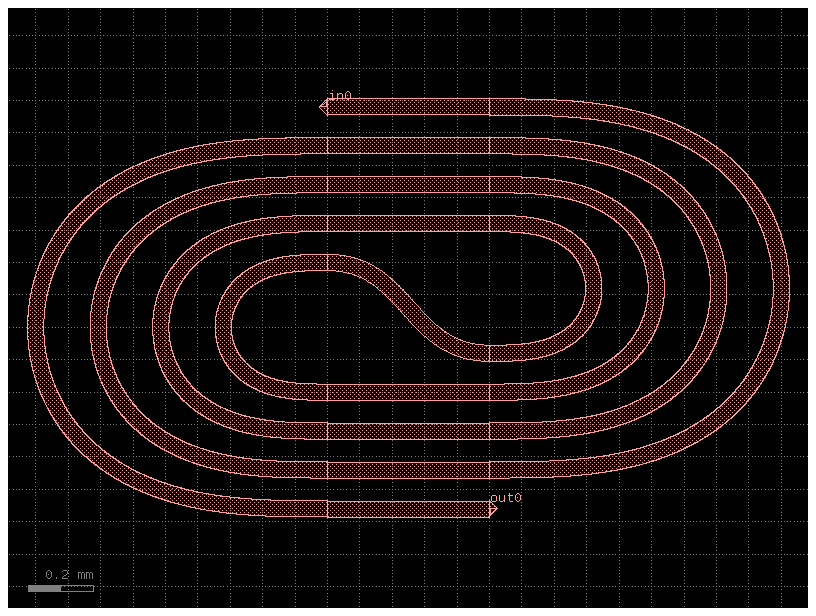

In [29]:
gf.clear_cache()

@gf.cell
def espiral(espiral_length, radio_minimo, separacion_espiras, xs):
    espiral = gf.Component()

    # Creamos los componentes 
    espiral_cell = gf.components.spiral_racetrack(straight_length=espiral_length, 
                                                  min_radius=radio_minimo, 
                                                  spacings=(separacion_espiras, 
                                                            separacion_espiras, 
                                                            separacion_espiras, 
                                                            separacion_espiras), 
                                                            bend=gf.components.bend_euler, 
                                                            cross_section=xs)

    # Añadimos los componentes
    espiral1 = espiral.add_ref(espiral_cell)

    # Puertos exteriores
    espiral.add_port("in0", port=espiral1.ports["o1"])
    espiral.add_port("out0", port=espiral1.ports["o2"])

    return espiral


# Cross-section
xs = gf.cross_section.strip(width=50, layer="WG")

espiral1 = espiral(espiral_length=500, radio_minimo=200, separacion_espiras=120, xs=xs)

# Visualización
espiral1.draw_ports()
espiral1.plot()

### b) Creating die

#### b1) Create a die  W = 5 mm x L = 10 mm 

2026-06-12 14:48:46.874 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


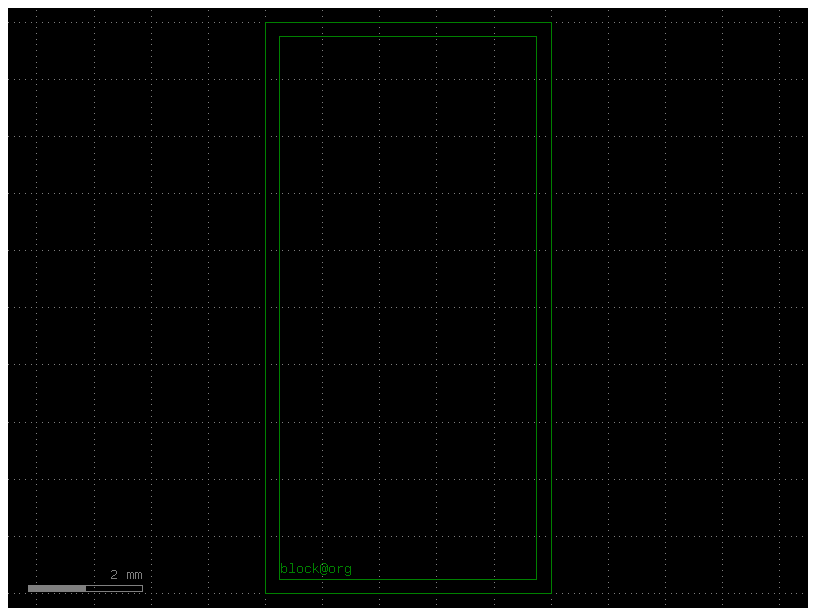

In [30]:
gf.clear_cache()

@gf.cell
def die(dieL=5000, dieW=5000, border=250, layer_box="FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieL, dieW), layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(
        size=(dieL-border*2, dieW-border*2), 
        layer=layer_box)).dmovex(border).dmovey(border)
    
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)

    # Adding ports to a component 
    box.add_port(name="block@org", center=[border, border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

# Create a die W = 5 mm x L = 10 mm
die1 = die(dieW=10000, dieL=5000, border=250, layer_box="FLOORPLAN")

die1.show()
die1.plot()

#### b2) Create an array of I/Os spaced at 250 µm (as much I/Os as the width allows)

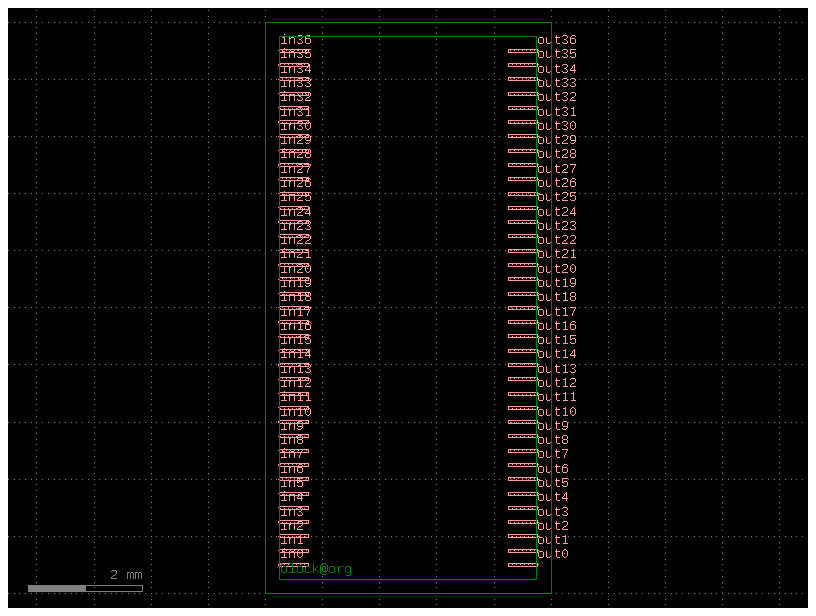

In [31]:
gf.clear_cache()

# Parámetros del die
dieL = 5000
dieW = 10000
border = 250

# Parámetros de los IOs
io_separacion = 250
io_length = 500
io_width = 50

# Margen
io_margen = border + io_separacion

# Número de IOs que caben en la anchura del die
n_ios = int((dieW - 2*io_margen) / io_separacion) + 1

# Cross-section
xs = gf.cross_section.strip(width=io_width, layer="WG")

layout_ios = gf.Component()

# Creamos los componentes y los añadimos
io = gf.components.straight(length=io_length, cross_section=xs)
die_ref = layout_ios.add_ref(die(dieL=dieL, dieW=dieW, border=border, layer_box="FLOORPLAN"))

# Añadimos el array de IOs a lo largo de la anchura del die
for i in range(n_ios):
    y = io_margen + io_separacion*i

    # Recta de entrada
    io_in = layout_ios.add_ref(io)
    io_in.movex(border)
    io_in.movey(y)

    # Recta de salida
    io_out = layout_ios.add_ref(io)
    io_out.movex(dieL - border - io_length)
    io_out.movey(y)

    # Puertos exteriores
    layout_ios.add_port(f"in{i}", port=io_in.ports["o1"])
    layout_ios.add_port(f"out{i}", port=io_out.ports["o2"])

# Visualización
layout_ios.draw_ports()
layout_ios.plot()

#### b3) Create a cell component of this die, with I/Os accessible to connect

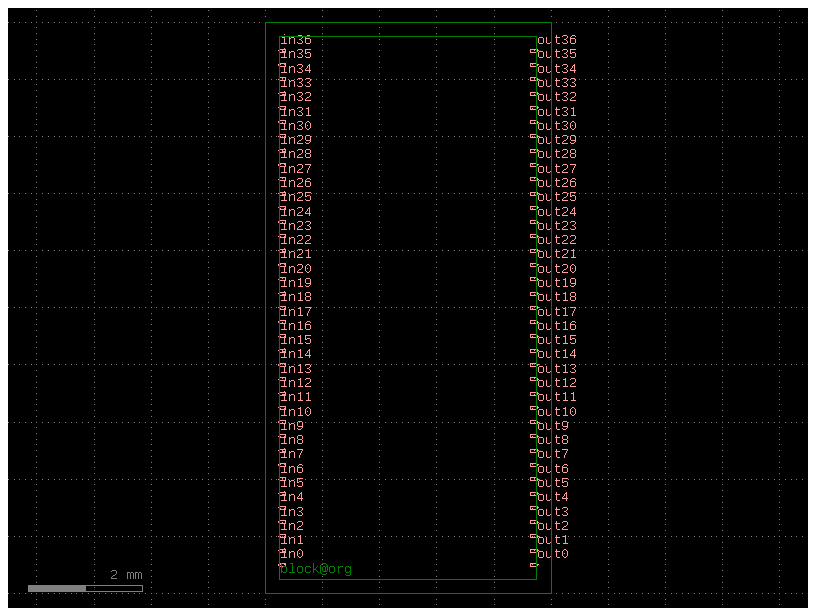

In [68]:
gf.clear_cache()

@gf.cell
def die_con_ios(dieL, dieW, border, io_separacion, io_length, io_width, xs):
    layout_ios = gf.Component()

    # Margen
    io_margen = border + io_separacion

    # Número de IOs que caben en la anchura del die
    n_ios = int((dieW - 2*io_margen) / io_separacion) + 1

    # Creamos los componentes
    io = gf.components.straight(length=io_length, cross_section=xs)
    die_ref = layout_ios.add_ref(die(dieL=dieL, dieW=dieW, border=border, layer_box="FLOORPLAN"))

    # Añadimos el array de IOs a lo largo de la anchura del die
    for i in range(n_ios):
        y = io_margen + io_separacion*i

        # Recta de entrada
        io_in = layout_ios.add_ref(io)
        io_in.movex(border)
        io_in.movey(y)

        # Recta de salida
        io_out = layout_ios.add_ref(io)
        io_out.movex(dieL - border - io_length)
        io_out.movey(y)

        # Puertos accesibles para conectar
        layout_ios.add_port(f"in{i}", port=io_in.ports["o1"])
        layout_ios.add_port(f"out{i}", port=io_out.ports["o2"])

    return layout_ios


# Parámetros del die
dieL = 5000
dieW = 10000
border = 250

# Parámetros de los IOs
io_separacion = 250
io_length = 100
io_width = 50

# Cross-section
xs = gf.cross_section.strip(width=io_width, layer="WG")

# Creamos la celda del die con IOs
die_ios1 = die_con_ios(
    dieL=dieL,
    dieW=dieW,
    border=border,
    io_separacion=io_separacion,
    io_length=io_length,
    io_width=io_width,
    xs=xs,
)

# Visualización
die_ios1.draw_ports()
die_ios1.plot()

### c) Floorplaning and die layout

#### c1) Make an instance of the die as host component for your layout

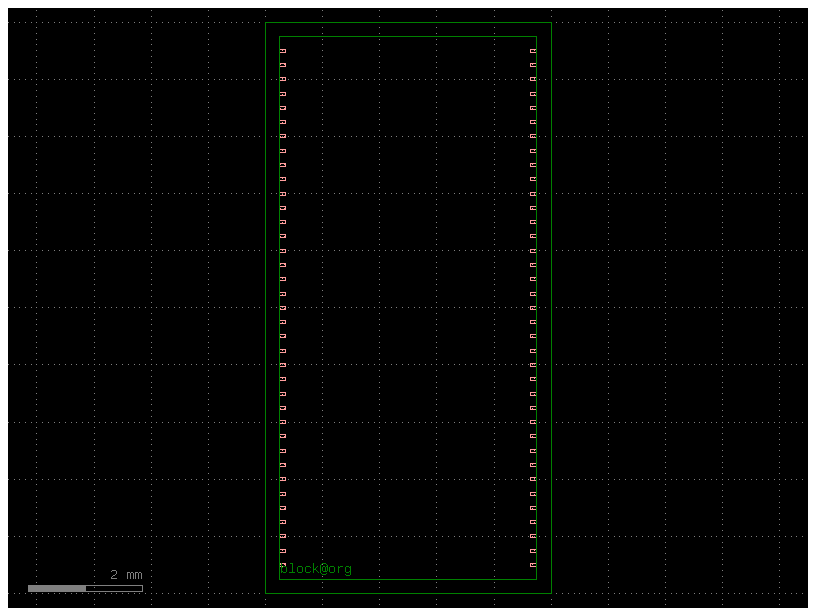

In [165]:
gf.clear_cache()

# Cross-section
xs = gf.cross_section.strip(width=io_width, layer="WG")

# Componente principal del layout
layout = gf.Component()

# Añadimos el die como host component
die_ref = layout.add_ref(
    die_con_ios(
        dieL=5000,
        dieW=10000,
        border=250,
        io_separacion=250,
        io_length=100,
        io_width=50,
        xs=xs,
    )
)

# Hacemos accesibles los puertos del die desde layout
for port in die_ref.ports:
    layout.add_port(port.name, port=port)

# Visualización
# layout.draw_ports()
layout.plot()

#### c2) Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die

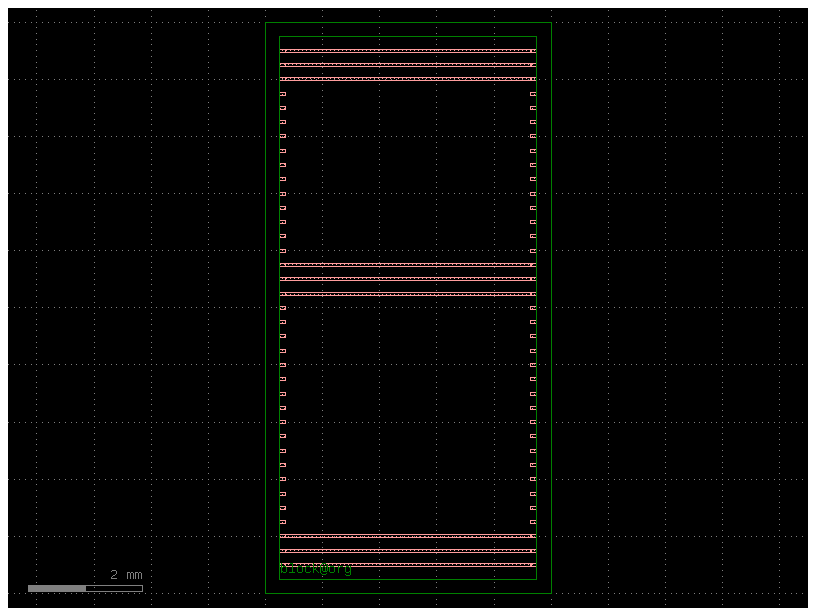

In [71]:
# Longitud de las rectas entre los IOs de entrada y salida
recta_length = dieL - 2*border - 2*io_length

# Creamos la guía recta
recta = gf.components.straight(length=recta_length, cross_section=xs)

# Posición inicial en X de las rectas internas
x_recta = border + io_length


# Rectas inferiores
recta_bottom0 = layout.add_ref(recta)
recta_bottom0.movex(x_recta)
recta_bottom0.movey(io_margen + io_separacion*0)

recta_bottom1 = layout.add_ref(recta)
recta_bottom1.movex(x_recta)
recta_bottom1.movey(io_margen + io_separacion*1)

recta_bottom2 = layout.add_ref(recta)
recta_bottom2.movex(x_recta)
recta_bottom2.movey(io_margen + io_separacion*2)


# Rectas centrales
recta_middle0 = layout.add_ref(recta)
recta_middle0.movex(x_recta)
recta_middle0.movey(io_margen + io_separacion*19)

recta_middle1 = layout.add_ref(recta)
recta_middle1.movex(x_recta)
recta_middle1.movey(io_margen + io_separacion*20)

recta_middle2 = layout.add_ref(recta)
recta_middle2.movex(x_recta)
recta_middle2.movey(io_margen + io_separacion*21)


# Rectas superiores
recta_top0 = layout.add_ref(recta)
recta_top0.movex(x_recta)
recta_top0.movey(io_margen + io_separacion*34)

recta_top1 = layout.add_ref(recta)
recta_top1.movex(x_recta)
recta_top1.movey(io_margen + io_separacion*35)

recta_top2 = layout.add_ref(recta)
recta_top2.movex(x_recta)
recta_top2.movey(io_margen + io_separacion*36)


# Visualización
# layout.draw_ports()
layout.plot()

#### c3) Add 2 of each of the components above, with different lengths

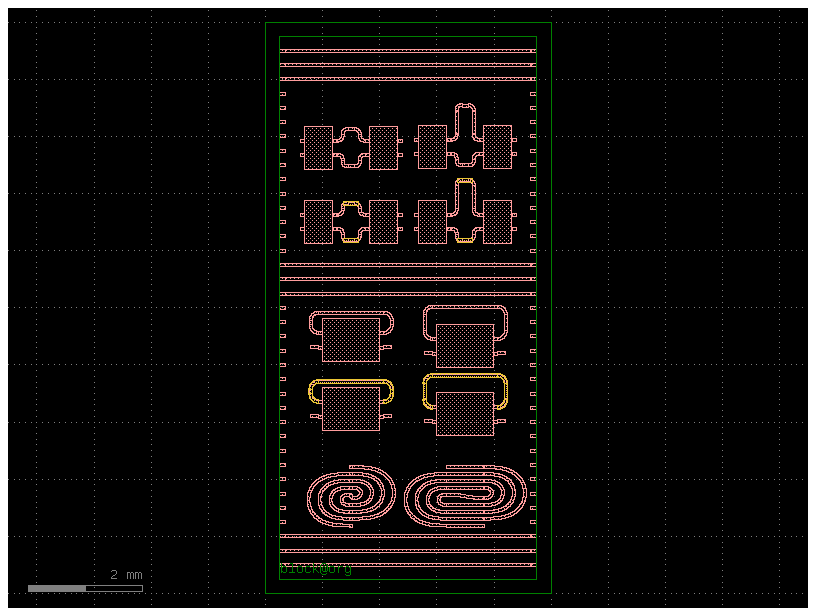

In [ ]:
gf.clear_cache()

# Cross-section
xs = gf.cross_section.strip(width=io_width, layer="WG")

# Componente principal del layout
layout = gf.Component()

# Añadimos el die como host component
die_ref = layout.add_ref(
    die_con_ios(
        dieL=5000,
        dieW=10000,
        border=250,
        io_separacion=250,
        io_length=100,
        io_width=50,
        xs=xs,
    )
)

# Hacemos accesibles los puertos del die desde layout
for port in die_ref.ports:
    layout.add_port(port.name, port=port)


# Longitud de las rectas entre los IOs de entrada y salida
recta_length = dieL - 2*border - 2*io_length

# Creamos la guía recta
recta = gf.components.straight(length=recta_length, cross_section=xs)

# Posición inicial en X de las rectas internas
x_recta = border + io_length


# Rectas inferiores
recta_bottom0 = layout.add_ref(recta)
recta_bottom0.movex(x_recta)
recta_bottom0.movey(io_margen + io_separacion*0)

recta_bottom1 = layout.add_ref(recta)
recta_bottom1.movex(x_recta)
recta_bottom1.movey(io_margen + io_separacion*1)

recta_bottom2 = layout.add_ref(recta)
recta_bottom2.movex(x_recta)
recta_bottom2.movey(io_margen + io_separacion*2)


# Rectas centrales
recta_middle0 = layout.add_ref(recta)
recta_middle0.movex(x_recta)
recta_middle0.movey(io_margen + io_separacion*19)

recta_middle1 = layout.add_ref(recta)
recta_middle1.movex(x_recta)
recta_middle1.movey(io_margen + io_separacion*20)

recta_middle2 = layout.add_ref(recta)
recta_middle2.movex(x_recta)
recta_middle2.movey(io_margen + io_separacion*21)


# Rectas superiores
recta_top0 = layout.add_ref(recta)
recta_top0.movex(x_recta)
recta_top0.movey(io_margen + io_separacion*34)

recta_top1 = layout.add_ref(recta)
recta_top1.movex(x_recta)
recta_top1.movey(io_margen + io_separacion*35)

recta_top2 = layout.add_ref(recta)
recta_top2.movex(x_recta)
recta_top2.movey(io_margen + io_separacion*36)

# Cross-section para los componentes internos
xs_componentes = gf.cross_section.strip(width=50, layer="WG")

# Añadimos 2 MZIs sin calentamiento, con distinta longitud
mzi1 = layout.add_ref(mzi(mmi_Lpi=1000,mmi_Width=750,mmi_recta_length=70,dL=0,recta_length_horizontal=100,xs=xs_componentes,codos90_radius=100))
mzi2 = layout.add_ref(mzi(mmi_Lpi=1000,mmi_Width=750,mmi_recta_length=70,dL=400,recta_length_horizontal=100,xs=xs_componentes,codos90_radius=100))

mzi1.center = (1500, 7800)
mzi2.center = (3500, 8000)

# # Añadimos 2 MZIs con calentamiento, con distinta longitud
mzi_thermal1 = layout.add_ref(mzi_thermal(dL=0,mmi_Lpi=1000,mmi_Width=750,mmi_recta_length=70,recta_length_horizontal=100,xs=xs_componentes,codos90_radius=100,heater_width=60,heater_length=260,layer_heater="HEATER"))
mzi_thermal2 = layout.add_ref(mzi_thermal(dL=400,mmi_Lpi=1000,mmi_Width=750,mmi_recta_length=70,recta_length_horizontal=100,xs=xs_componentes,codos90_radius=100,heater_width=60,heater_length=260,layer_heater="HEATER"))

mzi_thermal1.center = (1500, 6500)
mzi_thermal2.center = (3500, 6700)

# # Añadimos 2 rings sin calentamiento, con distinto extra_length
ring1 = layout.add_ref(ring_ap_mmi(extra_length=150,mmi_Lpi=2000,mmi_Width=750,mmi_recta_length=70,codos90_radius=140,xs=xs_componentes))
ring2 = layout.add_ref(ring_ap_mmi(extra_length=550,mmi_Lpi=2000,mmi_Width=750,mmi_recta_length=70,codos90_radius=140,xs=xs_componentes))

ring1.center = (1500, 4500)
ring2.center = (3500, 4500)

# # Añadimos 2 rings con calentamiento, con distinto extra_length
ring_thermal1 = layout.add_ref(ring_ap_mmi_thermal(extra_length=150,mmi_Lpi=2000,mmi_Width=750,mmi_recta_length=70,codos90_radius=140,xs=xs_componentes,heater_width=60,layer_heater="HEATER"))
ring_thermal2 = layout.add_ref(ring_ap_mmi_thermal(extra_length=550,mmi_Lpi=2000,mmi_Width=750,mmi_recta_length=70,codos90_radius=140,xs=xs_componentes,heater_width=60,layer_heater="HEATER"))

ring_thermal1.dcenter = (1500, 3300)
ring_thermal2.dcenter = (3500, 3300)

# # Añadimos 2 espirales, con distinta longitud
espiral1 = layout.add_ref(espiral(espiral_length=50,radio_minimo=90,separacion_espiras=120,xs=xs_componentes))
espiral2 = layout.add_ref(espiral(espiral_length=650,radio_minimo=90,separacion_espiras=120,xs=xs_componentes))

espiral1.dcenter = (1500, 1700)
espiral2.dcenter = (3500, 1700)


# Visualización
#layout.draw_ports()
layout.plot()

#### c4) Connect all your components to the I/Os 

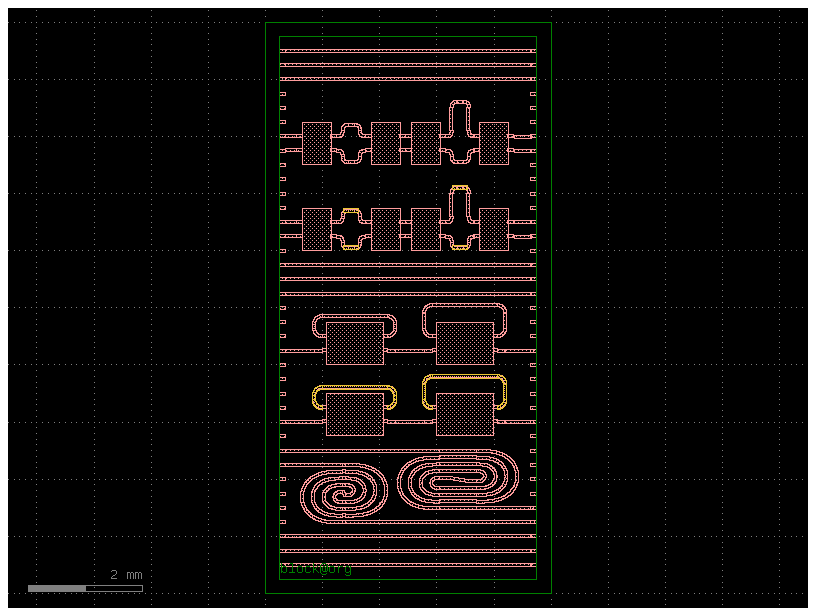

In [ ]:
gf.clear_cache()

# Cross-section
xs = gf.cross_section.strip(width=io_width, layer="WG")

# Componente principal del layout
layout = gf.Component()

# Añadimos el die como host component
die_ref = layout.add_ref(
    die_con_ios(
        dieL=5000,
        dieW=10000,
        border=250,
        io_separacion=250,
        io_length=100,
        io_width=50,
        xs=xs,
    )
)

# Hacemos accesibles los puertos del die desde layout
for port in die_ref.ports:
    layout.add_port(port.name, port=port)


# Longitud de las rectas entre los IOs de entrada y salida
recta_length = dieL - 2*border - 2*io_length

# Creamos la guía recta
recta = gf.components.straight(length=recta_length, cross_section=xs)

# Posición inicial en X de las rectas internas
x_recta = border + io_length


# Rectas inferiores
recta_bottom0 = layout.add_ref(recta)
recta_bottom0.movex(x_recta)
recta_bottom0.movey(io_margen + io_separacion*0)

recta_bottom1 = layout.add_ref(recta)
recta_bottom1.movex(x_recta)
recta_bottom1.movey(io_margen + io_separacion*1)

recta_bottom2 = layout.add_ref(recta)
recta_bottom2.movex(x_recta)
recta_bottom2.movey(io_margen + io_separacion*2)


# Rectas centrales
recta_middle0 = layout.add_ref(recta)
recta_middle0.movex(x_recta)
recta_middle0.movey(io_margen + io_separacion*19)

recta_middle1 = layout.add_ref(recta)
recta_middle1.movex(x_recta)
recta_middle1.movey(io_margen + io_separacion*20)

recta_middle2 = layout.add_ref(recta)
recta_middle2.movex(x_recta)
recta_middle2.movey(io_margen + io_separacion*21)


# Rectas superiores
recta_top0 = layout.add_ref(recta)
recta_top0.movex(x_recta)
recta_top0.movey(io_margen + io_separacion*34)

recta_top1 = layout.add_ref(recta)
recta_top1.movex(x_recta)
recta_top1.movey(io_margen + io_separacion*35)

recta_top2 = layout.add_ref(recta)
recta_top2.movex(x_recta)
recta_top2.movey(io_margen + io_separacion*36)


# Cross-section para los componentes internos
xs_componentes = gf.cross_section.strip(width=50, layer="WG")


# Añadimos 2 MZIs sin calentamiento, con distinta longitud
mzi1 = layout.add_ref(mzi(mmi_Lpi=1000,mmi_Width=750,mmi_recta_length=100,dL=0,recta_length_horizontal=100,xs=xs_componentes,codos90_radius=100))
mzi2 = layout.add_ref(mzi(mmi_Lpi=1000,mmi_Width=750,mmi_recta_length=100,dL=400,recta_length_horizontal=100,xs=xs_componentes,codos90_radius=100))

mzi1.center = (1500, 7800)
mzi2.center = (3500, 8000)

# # Añadimos 2 MZIs con calentamiento, con distinta longitud
mzi_thermal1 = layout.add_ref(mzi_thermal(dL=0,mmi_Lpi=1000,mmi_Width=750,mmi_recta_length=100,recta_length_horizontal=100,xs=xs_componentes,codos90_radius=100,heater_width=60,heater_length=260,layer_heater="HEATER"))
mzi_thermal2 = layout.add_ref(mzi_thermal(dL=400,mmi_Lpi=1000,mmi_Width=750,mmi_recta_length=100,recta_length_horizontal=100,xs=xs_componentes,codos90_radius=100,heater_width=60,heater_length=260,layer_heater="HEATER"))

mzi_thermal1.center = (1500, 6500)
mzi_thermal2.center = (3500, 6700)

# # Añadimos 2 rings sin calentamiento, con distinto extra_length
ring1 = layout.add_ref(ring_ap_mmi(extra_length=150,mmi_Lpi=2000,mmi_Width=750,mmi_recta_length=70,codos90_radius=140,xs=xs_componentes))
ring2 = layout.add_ref(ring_ap_mmi(extra_length=550,mmi_Lpi=2000,mmi_Width=750,mmi_recta_length=70,codos90_radius=140,xs=xs_componentes))

ring1.center = (1500, 4500)
ring2.center = (3500, 4500)

# # Añadimos 2 rings con calentamiento, con distinto extra_length
ring_thermal1 = layout.add_ref(ring_ap_mmi_thermal(extra_length=150,mmi_Lpi=2000,mmi_Width=750,mmi_recta_length=70,codos90_radius=140,xs=xs_componentes,heater_width=60,layer_heater="HEATER"))
ring_thermal2 = layout.add_ref(ring_ap_mmi_thermal(extra_length=550,mmi_Lpi=2000,mmi_Width=750,mmi_recta_length=70,codos90_radius=140,xs=xs_componentes,heater_width=60,layer_heater="HEATER"))

ring_thermal1.dcenter = (1500, 3300)
ring_thermal2.dcenter = (3500, 3300)

# # Añadimos 2 espirales, con distinta longitud
espiral1 = layout.add_ref(espiral(espiral_length=50,radio_minimo=90,separacion_espiras=118,xs=xs_componentes))
espiral2 = layout.add_ref(espiral(espiral_length=650,radio_minimo=90,separacion_espiras=118,xs=xs_componentes))

espiral1.dcenter = (1500, 1700)
espiral2.dcenter = (3500, 1700)


####### MZI
recta_in30 = gf.components.straight(length=200, cross_section=xs_componentes)
recta_in30_ref = layout.add_ref(recta_in30)
recta_in30_ref.movex(border + io_length)
recta_in30_ref.movey(io_margen + io_separacion*30)
mzi1.connect("in0", recta_in30_ref.ports["o2"])
mzi2.connect("in0", mzi1.ports["out0"])
recta_in29_ref = layout.add_ref(recta_in30)
recta_in29_ref.movex(border + io_length)
recta_in29_ref.movey(io_margen + io_separacion*29)
recta_out29 = gf.components.straight(length=300, cross_section=xs_componentes)
recta_out29_ref = layout.add_ref(recta_out29)
recta_out30_ref = layout.add_ref(recta_out29)
recta_out30_ref.connect("o1", mzi2.ports["out0"])
recta_out29_ref.connect("o1", mzi2.ports["out1"])

####### MZI THERM
recta_in24_ref = layout.add_ref(recta_in30)
recta_in24_ref.movex(border + io_length)
recta_in24_ref.movey(io_margen + io_separacion*24)
mzi_thermal1.connect("in0", recta_in24_ref.ports["o2"])
mzi_thermal2.connect("in0", mzi_thermal1.ports["out0"])
recta_in23_ref = layout.add_ref(recta_in30)
recta_in23_ref.movex(border + io_length)
recta_in23_ref.movey(io_margen + io_separacion*23)
recta_out23_ref = layout.add_ref(recta_out29)
recta_out24_ref = layout.add_ref(recta_out29)
recta_out24_ref.connect("o1", mzi_thermal2.ports["out0"])
recta_out23_ref.connect("o1", mzi_thermal2.ports["out1"])

####### RING
recta_in15 = gf.components.straight(length=500, cross_section=xs_componentes)
recta_in15_ref = layout.add_ref(recta_in15)
recta_in15_ref.movex(border + io_length)
recta_in15_ref.movey(io_margen + io_separacion*15)
ring1.connect("in0", recta_in15_ref.ports["o2"])
recta_in15_intermedia_ref = layout.add_ref(recta_in15)
recta_in15_intermedia_ref.connect("o1", ring1.ports["out0"])
ring2.connect("in0", recta_in15_intermedia_ref.ports["o2"])
recta_out15_ref = layout.add_ref(recta_in15)
recta_out15_ref.connect("o1", ring2.ports["out0"])

####### RING THERMAL
recta_in10_ref = layout.add_ref(recta_in15)
recta_in10_ref.movex(border + io_length)
recta_in10_ref.movey(io_margen + io_separacion*10)
ring_thermal1.connect("in0", recta_in10_ref.ports["o2"])
recta_in10_intermedia_ref = layout.add_ref(recta_in15)
recta_in10_intermedia_ref.connect("o1", ring_thermal1.ports["out0"])
ring_thermal2.connect("in0", recta_in10_intermedia_ref.ports["o2"])
recta_out10_ref = layout.add_ref(recta_in15)
recta_out10_ref.connect("o1", ring_thermal2.ports["out0"])

####### ESPIRALES
recta_in7 = gf.components.straight(length=1000, cross_section=xs_componentes)
recta_in7_ref = layout.add_ref(recta_in7)
recta_in7_ref.movex(border + io_length)
recta_in7_ref.movey(io_margen + io_separacion*7)
espiral1.connect("in0", recta_in7_ref.ports["o2"])
recta_in8 = gf.components.straight(length=2700, cross_section=xs_componentes)
recta_in8_ref = layout.add_ref(recta_in8)
recta_in8_ref.movex(border + io_length)
recta_in8_ref.movey(io_margen + io_separacion*8)
espiral2.connect("in0", recta_in8_ref.ports["o2"])
recta_out3 = gf.components.straight(length=3300, cross_section=xs_componentes)
recta_out3_ref = layout.add_ref(recta_out3)
recta_out3_ref.connect("o1", espiral1.ports["out0"])
recta_out4 = gf.components.straight(length=1000, cross_section=xs_componentes)
recta_out4_ref = layout.add_ref(recta_out4)
recta_out4_ref.connect("o1", espiral2.ports["out0"])

# Visualización
layout.plot()